In [1]:
# Install required packages
# Use prebuilt wheels for torch-scatter/torch-sparse to avoid slow source builds
import torch
tv = torch.__version__.split('+')[0]   # e.g. '2.6.0'
cv = torch.version.cuda.replace('.', '')  # e.g. '124'
whl = f'https://data.pyg.org/whl/torch-{tv}+cu{cv}.html'
print(f'PyG wheel index: {whl}')
!pip install -q torch-scatter torch-sparse -f {whl}
!pip install -q torch-geometric scipy pandas matplotlib seaborn tqdm pyarrow fastparquet scikit-learn

PyG wheel index: https://data.pyg.org/whl/torch-2.11.0+cu128.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 139.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 95.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 82.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 105.5 MB/s eta 0:00:00


In [2]:
# Clone the repository and add src to sys.path
import os
import sys

REPO_ROOT = '/content/antenna-gnn'

if not os.path.exists(REPO_ROOT):
    !git clone https://github.com/asparagusD/antenna_gnn.git {REPO_ROOT}
else:
    !cd {REPO_ROOT} && git pull

if f'{REPO_ROOT}/src' not in sys.path:
    sys.path.insert(0, f'{REPO_ROOT}/src')

Cloning into '/content/antenna-gnn'...
remote: Enumerating objects: 307, done.
remote: Counting objects: 100% (307/307), done.
remote: Compressing objects: 100% (178/178), done.
remote: Total 307 (delta 160), reused 259 (delta 114), pack-reused 0 (from 0)
Receiving objects: 100% (307/307), 7.05 MiB | 5.98 MiB/s, done.
Resolving deltas: 100% (160/160), done.


In [3]:
# Mount Google Drive and set data paths
from google.colab import drive
import os

drive.mount('/content/drive')

DATA_ROOT = '/content/drive/MyDrive/antenna_gnn'
RAW_DATA = '/content/drive/MyDrive/antenna_dataset'

# Create necessary directories in DATA_ROOT
os.makedirs(f'{DATA_ROOT}/artifacts', exist_ok=True)
os.makedirs(f'{DATA_ROOT}/figures', exist_ok=True)
os.makedirs(f'{DATA_ROOT}/checkpoints', exist_ok=True)

Mounted at /content/drive


---
## Cell A — Setup, Frozen and Shared Across All Arms

Load normalization stats, splits, frequency axis. Draw a grid-stratified
2,000-sample subset from the 11,971 pool (seed=22). Define the
`FinetuneDataset`, local disk caching, and normalization guard.

Fine-tune configuration (identical for every arm):
- Parent: `best_model.pt` (25×25 pre-train)
- Strategy A full fine-tune: lr=1e-4, weight_decay=1e-4, batch=128,
  grad_clip=1.0, ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-6),
  early stopping patience=10, max_epochs=60
- NO TF32, NO bf16, num_workers=0

In [4]:
# ==========================================================================
# CELL A — Setup, Frozen and Shared Across All Arms
# ==========================================================================

import json
import hashlib
import shutil
import time
import copy
import glob as glob_mod
import subprocess
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from collections import defaultdict
from torch.nn.utils import clip_grad_norm_
from torch.utils.data import Dataset as TorchDataset
from torch_geometric.loader import DataLoader
from scipy.signal import find_peaks
from scipy import stats as scipy_stats
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             roc_curve, precision_recall_curve,
                             balanced_accuracy_score, f1_score,
                             precision_score, recall_score,
                             confusion_matrix)
from tqdm.notebook import tqdm
from model import AntennaGNN

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# ── Disable TF32 ──
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False
print('TF32 disabled')

# ── FinetuneDataset — frozen — validated in Chunk 13 ──
class FinetuneDataset(TorchDataset):
    """Fine-tune graph dataset with mandatory z-score normalization at load.

    On-disk data.y is raw dB. This dataset z-scores y at load time using
    the 25x25 training-split s11_mean / s11_std, and preserves y_raw.
    evaluate() de-normalizes with the same statistics.

    Never pass s11_mean=None or s11_std=None.
    """

    def __init__(self, indices, processed_dir_base, s11_mean, s11_std):
        assert s11_mean is not None, 'FinetuneDataset requires s11_mean (got None)'
        assert s11_std is not None,  'FinetuneDataset requires s11_std (got None)'
        self.indices = indices
        self.processed_dir_base = processed_dir_base
        self.s11_mean = s11_mean   # (201,) tensor
        self.s11_std  = s11_std    # (201,) tensor

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        grid_size, local_idx = self.indices[idx]
        path = f'{self.processed_dir_base}/{grid_size}x{grid_size}/sample_{local_idx}.pt'
        data = torch.load(path, weights_only=False)

        # Preserve raw dB target, then z-score
        data.y_raw = data.y.clone()                              # (1, 201) raw dB
        data.y = (data.y - self.s11_mean) / (self.s11_std + 1e-8)  # (1, 201) normalized

        return data


# ── Frequency axis ──
freq_axis = np.linspace(1.0, 4.0, 201)

# ── Load statistics ──
s11_mean_np = np.load(f'{DATA_ROOT}/artifacts/s11_mean.npy')
s11_std_np  = np.load(f'{DATA_ROOT}/artifacts/s11_std.npy')
s11_mean_cpu = torch.tensor(s11_mean_np, dtype=torch.float32)
s11_std_cpu  = torch.tensor(s11_std_np,  dtype=torch.float32)
s11_mean_dev = s11_mean_cpu.to(device)
s11_std_dev  = s11_std_cpu.to(device)
assert s11_mean_cpu.shape == (201,) and s11_std_cpu.shape == (201,)
print(f'Loaded s11_mean and s11_std, shape (201,)')

# ── Load splits ──
with open(f'{DATA_ROOT}/splits/finetune_pool_indices.json') as f:
    pool_indices = json.load(f)
with open(f'{DATA_ROOT}/splits/finetune_val_indices.json') as f:
    val_indices = json.load(f)
# NOTE: test indices are intentionally NOT loaded in this notebook.
TEST_INDICES_LOADED = False

print(f'Pool: {len(pool_indices)}, Val: {len(val_indices)}')

# ── Draw grid-stratified 2,000-sample subset ──
subset_path = f'{DATA_ROOT}/artifacts/ch22_subset_2000.json'

if os.path.exists(subset_path):
    with open(subset_path) as f:
        subset_indices = json.load(f)
    print(f'Loaded existing subset: {len(subset_indices)} samples')
else:
    rng = np.random.RandomState(22)
    pool_df = pd.DataFrame(pool_indices, columns=['grid_size', 'local_idx'])

    # Stratified sample: sample proportionally by grid size
    subset_rows = []
    for g, group in pool_df.groupby('grid_size'):
        n_g = len(group)
        n_sample = round(n_g / len(pool_df) * 2000)
        sampled = group.sample(n=n_sample, random_state=rng)
        subset_rows.append(sampled)

    subset_df = pd.concat(subset_rows)
    # Adjust to exactly 2000 if rounding pushed us off
    if len(subset_df) > 2000:
        subset_df = subset_df.sample(n=2000, random_state=rng)
    elif len(subset_df) < 2000:
        remaining = pool_df.drop(subset_df.index)
        extra = remaining.sample(n=2000 - len(subset_df), random_state=rng)
        subset_df = pd.concat([subset_df, extra])

    subset_indices = subset_df[['grid_size', 'local_idx']].values.tolist()
    with open(subset_path, 'w') as f:
        json.dump(subset_indices, f)
    print(f'Drew and saved subset: {len(subset_indices)} samples')

# Print per-grid composition
sub_df = pd.DataFrame(subset_indices, columns=['grid_size', 'local_idx'])
print(f'\nSubset composition ({len(subset_indices)} samples):')
for g, group in sub_df.groupby('grid_size'):
    print(f'  Grid {g}x{g}: {len(group)} samples ({len(group)/len(subset_indices)*100:.1f}%)')

# Compute hash of subset for guard in Cell H
SUBSET_HASH = hashlib.sha256(json.dumps(subset_indices, sort_keys=True).encode()).hexdigest()
print(f'Subset hash: {SUBSET_HASH[:16]}...')

# ── Local disk caching (only needed files, not entire dataset) ──
processed_dir = f'{DATA_ROOT}/data/processed_finetune'
STAGE_LOCALLY = True

if STAGE_LOCALLY:
    drive_dir = f'{DATA_ROOT}/data/processed_finetune'
    local_dir = '/content/processed_finetune'
    try:
        # Only stage the files this notebook actually needs:
        # subset (2,000 train) + val (1,496) = ~3,500 files
        needed = set()
        for gs, li in subset_indices + val_indices:
            needed.add((gs, li))
        n_need = len(needed)
        print(f'Need {n_need} unique files (subset + val)')

        # Estimate size from a probe
        probe_idx = list(needed)[:20]
        probe_sizes = []
        for gs, li in probe_idx:
            p = f'{drive_dir}/{gs}x{gs}/sample_{li}.pt'
            if os.path.exists(p):
                probe_sizes.append(os.path.getsize(p))
        est_gb = (sum(probe_sizes) / len(probe_sizes)) * n_need / 1e9 if probe_sizes else 0
        free_gb = shutil.disk_usage('/content').free / 1e9
        print(f'~{est_gb:.2f} GB estimated, {free_gb:.1f} GB free on /content')
        assert free_gb > est_gb * 1.5, 'not enough local disk'

        t0 = time.time()
        os.makedirs(local_dir, exist_ok=True)
        n_copied = 0
        for gs, li in tqdm(sorted(needed), desc='Staging needed files'):
            src_path = f'{drive_dir}/{gs}x{gs}/sample_{li}.pt'
            dst_dir = f'{local_dir}/{gs}x{gs}'
            dst_path = f'{dst_dir}/sample_{li}.pt'
            if not os.path.exists(dst_path):
                os.makedirs(dst_dir, exist_ok=True)
                shutil.copy2(src_path, dst_path)
                n_copied += 1
        print(f'staged {n_copied} new files ({n_need} total needed) '
              f'in {time.time() - t0:.0f} s')
        processed_dir = local_dir
        print(f'processed_dir -> {processed_dir}')

    except Exception as e:
        print(f'staging skipped ({type(e).__name__}: {e})')
        print(f'continuing on Drive')

# ── Build DataLoaders ──
train_ds = FinetuneDataset(subset_indices, processed_dir, s11_mean_cpu, s11_std_cpu)
val_ds   = FinetuneDataset(val_indices, processed_dir, s11_mean_cpu, s11_std_cpu)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True,
                          num_workers=0, generator=torch.Generator().manual_seed(42))
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)

print(f'\nTrain: {len(train_ds)}, Val: {len(val_ds)}')
print(f'Train batches: {len(train_loader)}, Val batches: {len(val_loader)}')

# ── CANONICAL NORMALIZATION GUARD (identity version, exactly as Chunk 21 Cell A) ──
probe_loader = DataLoader(val_ds, batch_size=64, shuffle=False)
ys, yr = [], []
for b in tqdm(probe_loader, desc='Normalization Guard'):
    ys.append(b.y.view(-1, 201))
    yr.append(b.y_raw.view(-1, 201))
all_y, all_raw = torch.cat(ys), torch.cat(yr)

assert hasattr(val_ds[0], 'y_raw'), 'y_raw missing'
assert not torch.allclose(all_y, all_raw), 'y == y_raw — normalization is a no-op'
recon = all_y * s11_std_cpu + s11_mean_cpu
maxdiff = (recon - all_raw).abs().max().item()
assert maxdiff < 1e-3, f'round trip FAILED: max diff {maxdiff:.6f}'
assert all_raw.max().item() <= 0.01, \
    f'raw y max {all_raw.max().item():.3f} > 0 dB'
print(f'\u2713 Normalization guard passed (round trip max diff: {maxdiff:.2e})')
del probe_loader, ys, yr, all_y, all_raw, recon

# ── Get git SHA ──
try:
    GIT_SHA = subprocess.check_output(
        ['git', 'rev-parse', '--short', 'HEAD'],
        cwd=REPO_ROOT, stderr=subprocess.DEVNULL
    ).decode().strip()
except Exception:
    GIT_SHA = 'unknown'
print(f'Git SHA: {GIT_SHA}')

print('\n' + '=' * 60)
print('FINE-TUNE CONFIGURATION (identical for every arm):')
print('=' * 60)
print(f'  Parent checkpoint:  best_model.pt (25x25 pre-train)')
print(f'  lr = 1e-4, weight_decay = 1e-4')
print(f'  batch_size = 128, grad_clip_norm = 1.0')
print(f'  ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-6)')
print(f'  Early stopping patience = 10, max_epochs = 60')
print(f'  NO TF32, NO bf16, num_workers = 0')
print(f'  Training subset: {len(subset_indices)} samples (seed=22)')

Device: cuda
TF32 disabled
Loaded s11_mean and s11_std, shape (201,)
Pool: 11971, Val: 1496
Loaded existing subset: 2000 samples

Subset composition (2000 samples):
  Grid 35x35: 667 samples (33.4%)
  Grid 45x45: 933 samples (46.7%)
  Grid 55x55: 400 samples (20.0%)
Subset hash: 2bd670ddd6b55a20...
Need 3496 unique files (subset + val)
~1.03 GB estimated, 70.2 GB free on /content


Staging needed files:   0%|          | 0/3496 [00:00<?, ?it/s]

staged 3496 new files (3496 total needed) in 2854 s
processed_dir -> /content/processed_finetune

Train: 2000, Val: 1496
Train batches: 16, Val batches: 47


Normalization Guard:   0%|          | 0/24 [00:00<?, ?it/s]

✓ Normalization guard passed (round trip max diff: 1.91e-06)
Git SHA: 4a4c2ab

FINE-TUNE CONFIGURATION (identical for every arm):
  Parent checkpoint:  best_model.pt (25x25 pre-train)
  lr = 1e-4, weight_decay = 1e-4
  batch_size = 128, grad_clip_norm = 1.0
  ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-6)
  Early stopping patience = 10, max_epochs = 60
  NO TF32, NO bf16, num_workers = 0
  Training subset: 2000 samples (seed=22)


---
## Cell B — Loss Implementations

All four loss functions as small callables taking `(pred_norm, batch)` and
returning a scalar. This makes the training loop arm-agnostic.

- **L0**: `F.mse_loss(pred, y)` (control)
- **L1**: `F.huber_loss(pred, y, delta=1.0)`
- **L2**: Weighted MSE with `w = s11_std² / mean(s11_std²)`
- **L3**: L2 + λ · |softmin(pred_dB) − min(y_raw)|, λ auto-calibrated

In [5]:
# ==========================================================================
# CELL B — Loss Implementations
# ==========================================================================

# ── Weight buffer for L2/L3 ──
std_sq = s11_std_cpu ** 2
w_cpu = std_sq / std_sq.mean()  # (201,), unit-mean
w_dev = w_cpu.to(device)        # registered on device
print(f'L2 weight: shape {w_dev.shape}, min={w_dev.min():.4f}, '
      f'max={w_dev.max():.4f}, mean={w_dev.mean():.4f}')

# ── L0: vanilla MSE ──
def loss_L0(pred_norm, batch):
    y = batch.y.squeeze(1)  # (B, 201)
    return F.mse_loss(pred_norm, y)

# ── L1: Huber loss ──
def loss_L1(pred_norm, batch):
    y = batch.y.squeeze(1)
    return F.huber_loss(pred_norm, y, delta=1.0)

# ── L2: weighted MSE ──
def loss_L2(pred_norm, batch):
    y = batch.y.squeeze(1)  # (B, 201)
    return ((pred_norm - y) ** 2 * w_dev).mean()

# ── L3: L2 + lam * softmin penalty ──
# lam is calibrated on the first batch and then frozen.
L3_LAM = None  # will be set on first call
L3_LAM_FROZEN = False

def softmin(x, tau=0.5):
    """Differentiable soft minimum along the last dim.
    softmin(x, tau) = -tau * logsumexp(-x / tau, dim=-1)
    """
    return -tau * torch.logsumexp(-x / tau, dim=-1)


def loss_L3(pred_norm, batch):
    global L3_LAM, L3_LAM_FROZEN

    y = batch.y.squeeze(1)  # (B, 201)
    l2_val = ((pred_norm - y) ** 2 * w_dev).mean()

    # De-normalize predictions to dB for softmin
    pred_db = pred_norm * s11_std_dev + s11_mean_dev  # (B, 201)
    y_raw = batch.y_raw.squeeze(1)  # (B, 201) raw dB

    # Softmin of predicted curve
    pred_softmin = softmin(pred_db, tau=0.5)  # (B,)
    # True minimum
    true_min = y_raw.min(dim=-1).values       # (B,)

    penalty = (pred_softmin - true_min).abs().mean()

    if not L3_LAM_FROZEN:
        # Calibrate lam on the first batch: penalty is ~15% of total loss
        with torch.no_grad():
            if penalty.item() > 0:
                L3_LAM = 0.15 * l2_val.item() / penalty.item()
            else:
                L3_LAM = 0.0
        L3_LAM_FROZEN = True
        print(f'  L3: auto-calibrated lam = {L3_LAM:.6f} '
              f'(L2={l2_val.item():.4f}, penalty={penalty.item():.4f})')

    return l2_val + L3_LAM * penalty


LOSS_FNS = {
    'L0': loss_L0,
    'L1': loss_L1,
    'L2': loss_L2,
    'L3': loss_L3,
}

# ── Sanity check: one-batch loss + gradient norm comparison ──
print('\n' + '=' * 80)
print('LOSS SANITY CHECK (one real batch)')
print('=' * 80)

# Load a fresh model for the probe
probe_model = AntennaGNN(hidden_dim=128, heads=8, edge_dim=16,
                         num_blocks=4, output_dim=201)
ckpt = torch.load(f'{DATA_ROOT}/checkpoints/best_model.pt',
                   map_location='cpu', weights_only=False)
probe_model.load_state_dict(ckpt['model_state'], strict=True)
probe_model = probe_model.to(device)
del ckpt

probe_batch = next(iter(train_loader)).to(device)

print(f'{"Arm":<6} {"Loss value":<14} {"Grad norm":<14} {"Status"}')
print('-' * 50)

for arm_name, loss_fn in LOSS_FNS.items():
    # Reset lam for L3 probe
    if arm_name == 'L3':
        L3_LAM = None
        L3_LAM_FROZEN = False

    probe_model.zero_grad()
    pred = probe_model(probe_batch)
    loss = loss_fn(pred, probe_batch)
    loss.backward()

    grad_norm = torch.nn.utils.clip_grad_norm_(
        probe_model.parameters(), max_norm=float('inf')).item()

    is_nan = not np.isfinite(loss.item()) or not np.isfinite(grad_norm)
    status = 'NaN!' if is_nan else 'OK'

    print(f'{arm_name:<6} {loss.item():<14.6f} {grad_norm:<14.4f} {status}')

del probe_model, probe_batch
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Reset L3 lam for actual training
L3_LAM = None
L3_LAM_FROZEN = False
print('\n(L3 lam reset for actual training)')

L2 weight: shape torch.Size([201]), min=0.0000, max=9.2786, mean=1.0000

LOSS SANITY CHECK (one real batch)
Arm    Loss value     Grad norm      Status
--------------------------------------------------
L0     0.679811       5.2096         OK
L1     0.209597       1.4496         OK
L2     0.615430       7.5847         OK
  L3: auto-calibrated lam = 0.012353 (L2=0.6269, penalty=7.6117)
L3     0.720900       7.8196         OK

(L3 lam reset for actual training)


---
## Cell C — Timing Probe Before Committing

Train arm L0 for exactly 2 epochs, measure seconds/epoch, and project
the Stage 1 wall time. If the projection exceeds 90 minutes, STOP.

In [6]:
# ==========================================================================
# CELL C — Timing Probe Before Committing
# ==========================================================================

# Fresh model from best_model.pt
torch.manual_seed(42)
timing_model = AntennaGNN(hidden_dim=128, heads=8, edge_dim=16,
                          num_blocks=4, output_dim=201)
ckpt = torch.load(f'{DATA_ROOT}/checkpoints/best_model.pt',
                   map_location='cpu', weights_only=False)
timing_model.load_state_dict(ckpt['model_state'], strict=True)
timing_model = timing_model.to(device)
del ckpt

optimizer = torch.optim.Adam(timing_model.parameters(), lr=1e-4, weight_decay=1e-4)

epoch_times = []
for epoch in range(2):
    t0 = time.time()
    timing_model.train()
    for batch in tqdm(train_loader, desc=f'Timing epoch {epoch+1}/2', leave=False):
        batch = batch.to(device)
        optimizer.zero_grad()
        pred = timing_model(batch)
        loss = F.mse_loss(pred, batch.y.squeeze(1))
        loss.backward()
        clip_grad_norm_(timing_model.parameters(), max_norm=1.0)
        optimizer.step()
    elapsed = time.time() - t0
    epoch_times.append(elapsed)
    print(f'  Epoch {epoch+1}: {elapsed:.1f} s')

sec_per_epoch = np.mean(epoch_times)
# Stage 1 = 3 arms x ~25 epochs (conservative estimate, early stopping may cut)
projected_s1 = 3 * sec_per_epoch * 25
projected_min = projected_s1 / 60

print(f'\nAverage: {sec_per_epoch:.1f} s/epoch')
print(f'Projected Stage 1 (3 arms x 25 epochs): {projected_min:.0f} minutes')

if projected_min > 90:
    print('\n' + '!' * 80)
    print(f'WARNING: Projected Stage 1 = {projected_min:.0f} min > 90 min.')
    print(f'RECOMMENDATION: Drop to a 1,000-sample subset and re-run.')
    print(f'DO NOT CONTINUE AUTOMATICALLY.')
    print('!' * 80)
else:
    print(f'\u2713 Within 90-minute budget. Proceeding to Stage 1.')

del timing_model, optimizer
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Timing epoch 1/2:   0%|          | 0/16 [00:00<?, ?it/s]

  Epoch 1: 9.6 s


Timing epoch 2/2:   0%|          | 0/16 [00:00<?, ?it/s]

  Epoch 2: 9.0 s

Average: 9.3 s/epoch
Projected Stage 1 (3 arms x 25 epochs): 12 minutes
✓ Within 90-minute budget. Proceeding to Stage 1.


---
## Cell D — Stage 1: Run Arms L0, L1, L2

For each arm: fresh model from `best_model.pt`, train with early stopping
on validation loss in that arm's own loss, additionally log validation S11 MAE
in dB (the cross-arm comparable metric). Save checkpoints and provenance.

In [7]:
# ==========================================================================
# CELL D — Stage 1: Run Arms L0, L1, L2
# ==========================================================================

# ── Arm-agnostic training loop ──
def train_arm(arm_name, loss_fn, train_loader, val_loader,
              max_epochs=60, lr=1e-4, patience=10, max_norm=1.0):
    """Train one arm. Returns (model, best_state, history_dict)."""

    torch.manual_seed(42)  # identical seed for every arm
    np.random.seed(42)

    # Fresh model from best_model.pt
    model = AntennaGNN(hidden_dim=128, heads=8, edge_dim=16,
                       num_blocks=4, output_dim=201)
    ckpt = torch.load(f'{DATA_ROOT}/checkpoints/best_model.pt',
                       map_location='cpu', weights_only=False)
    model.load_state_dict(ckpt['model_state'], strict=True)
    model = model.to(device)
    del ckpt

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)

    best_val_loss = float('inf')
    best_val_mae = float('inf')
    best_state = None
    best_epoch = -1
    epochs_no_improve = 0
    grad_norms = []
    history = []

    t0_wall = time.time()

    for epoch in tqdm(range(max_epochs), desc=f'Arm {arm_name}'):
        model.train()
        epoch_loss = 0.0
        n_batches = 0

        for batch in tqdm(train_loader, desc=f'{arm_name} E{epoch+1}',
                          leave=False):
            batch = batch.to(device)
            optimizer.zero_grad()
            pred = model(batch)
            loss = loss_fn(pred, batch)
            loss.backward()

            pre_clip = clip_grad_norm_(
                [p for p in model.parameters() if p.requires_grad],
                max_norm=max_norm
            ).item()
            grad_norms.append(pre_clip)

            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1

        avg_loss = epoch_loss / n_batches

        # Validate — compute both arm-own loss and S11 MAE in dB
        model.eval()
        val_losses = []
        val_s11_errors = []
        with torch.no_grad():
            for vbatch in val_loader:
                vbatch = vbatch.to(device)
                vpred = model(vbatch)
                vloss = loss_fn(vpred, vbatch)
                val_losses.append(vloss.item())

                # S11 MAE in dB (cross-arm comparable)
                pred_db = vpred * s11_std_dev + s11_mean_dev
                true_db = vbatch.y_raw.squeeze(1).to(device)
                val_s11_errors.append(
                    (pred_db - true_db).abs().mean().item())

        val_loss = np.mean(val_losses)
        val_mae = np.mean(val_s11_errors)
        scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]['lr']
        clip_frac = (np.array(grad_norms[-n_batches:]) > max_norm).mean() * 100

        history.append({
            'epoch': epoch + 1,
            'train_loss': avg_loss,
            'val_loss': val_loss,
            'val_s11_mae': val_mae,
            'lr': current_lr,
            'clip_frac': clip_frac,
        })

        print(f'  {arm_name} E{epoch+1:2d}: loss={avg_loss:.4f} '
              f'val_loss={val_loss:.4f} val_mae={val_mae:.4f} '
              f'lr={current_lr:.2e} clip={clip_frac:.0f}%')

        # Divergence guard
        if not np.isfinite(val_loss):
            print(f'  {arm_name}: diverged at epoch {epoch+1}')
            break

        # Early stopping on arm-own val loss
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_mae = val_mae
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            best_epoch = epoch + 1
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f'  {arm_name}: early stopping at epoch {epoch+1}')
                break

    wall_clock = time.time() - t0_wall
    epochs_run = epoch + 1

    if best_state is None:
        raise RuntimeError(
            f'{arm_name}: training never produced a finite val loss')

    # Restore best
    model.load_state_dict(best_state)
    model.to(device)

    return model, best_state, {
        'arm': arm_name,
        'best_epoch': best_epoch,
        'epochs_run': epochs_run,
        'best_val_loss': best_val_loss,
        'best_val_mae': best_val_mae,
        'wall_clock_s': wall_clock,
        'grad_norms': grad_norms,
        'history': history,
    }


# ── Run Stage 1: L0, L1, L2 ──
stage1_arms = ['L0', 'L1', 'L2']
arm_models = {}   # {name: model}
arm_results = {}  # {name: history_dict}

for arm_name in stage1_arms:
    # Reset L3 lam (not used here, but defensive)
    L3_LAM = None
    L3_LAM_FROZEN = False

    print(f'\n{"="*60}')
    print(f'ARM {arm_name}')
    print(f'{"="*60}')

    model, best_state, result = train_arm(
        arm_name, LOSS_FNS[arm_name],
        train_loader, val_loader,
        max_epochs=60, lr=1e-4, patience=10, max_norm=1.0)

    arm_models[arm_name] = model
    arm_results[arm_name] = result

    # Save checkpoint
    ckpt_path = f'{DATA_ROOT}/checkpoints/ch22_{arm_name}.pt'
    torch.save({
        'model_state': best_state,
        'arm': arm_name,
        'best_epoch': result['best_epoch'],
        'best_val_mae': result['best_val_mae'],
    }, ckpt_path)

    # Save provenance
    loss_params = {'name': arm_name}
    if arm_name == 'L1':
        loss_params['delta'] = 1.0
    elif arm_name == 'L2':
        loss_params['weighting'] = 's11_std_sq_normalized'
    elif arm_name == 'L3':
        loss_params['lam'] = L3_LAM
        loss_params['softmin_tau'] = 0.5

    provenance = {
        'parent_checkpoint': 'best_model.pt',
        'loss': loss_params,
        'subset_indices_file': 'ch22_subset_2000.json',
        'subset_hash': SUBSET_HASH,
        'seed': 42,
        'lr': 1e-4,
        'weight_decay': 1e-4,
        'batch_size': 128,
        'grad_clip_norm': 1.0,
        'scheduler': 'ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-6)',
        'early_stopping_patience': 10,
        'max_epochs': 60,
        'epochs_run': result['epochs_run'],
        'best_epoch': result['best_epoch'],
        'best_val_loss': result['best_val_loss'],
        'best_val_mae': result['best_val_mae'],
        'wall_clock_s': result['wall_clock_s'],
        'git_sha': GIT_SHA,
    }
    prov_path = f'{DATA_ROOT}/checkpoints/ch22_{arm_name}_provenance.json'
    with open(prov_path, 'w') as f:
        json.dump(provenance, f, indent=2)

    print(f'\u2713 Saved {ckpt_path} and provenance')
    print(f'  Best epoch: {result["best_epoch"]}, '
          f'val S11 MAE: {result["best_val_mae"]:.4f} dB, '
          f'wall: {result["wall_clock_s"]/60:.1f} min')

    # Free GPU
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# ── Summary ──
print('\n' + '=' * 60)
print('STAGE 1 SUMMARY')
print('=' * 60)
print(f'{"Arm":<6} {"Best Epoch":<12} {"Val Loss":<12} {"Val S11 MAE":<14} {"Wall (min)":<10}')
print('-' * 55)
for arm_name in stage1_arms:
    r = arm_results[arm_name]
    print(f'{arm_name:<6} {r["best_epoch"]:<12} {r["best_val_loss"]:<12.4f} '
          f'{r["best_val_mae"]:<14.4f} {r["wall_clock_s"]/60:<10.1f}')


ARM L0


Arm L0:   0%|          | 0/60 [00:00<?, ?it/s]

L0 E1:   0%|          | 0/16 [00:00<?, ?it/s]

  L0 E 1: loss=0.5738 val_loss=0.5606 val_mae=0.4506 lr=1.00e-04 clip=100%


L0 E2:   0%|          | 0/16 [00:00<?, ?it/s]

...

  L2 E24: loss=0.1915 val_loss=0.2388 val_mae=0.3651 lr=5.00e-05 clip=81%


L2 E25:   0%|          | 0/16 [00:00<?, ?it/s]

  L2 E25: loss=0.1887 val_loss=0.2387 val_mae=0.3606 lr=5.00e-05 clip=81%


L2 E26:   0%|          | 0/16 [00:00<?, ?it/s]

  L2 E26: loss=0.1904 val_loss=0.2372 val_mae=0.3575 lr=5.00e-05 clip=62%
  L2: early stopping at epoch 26
✓ Saved /content/drive/MyDrive/antenna_gnn/checkpoints/ch22_L2.pt and provenance
  Best epoch: 16, val S11 MAE: 0.3570 dB, wall: 5.3 min

STAGE 1 SUMMARY
Arm    Best Epoch   Val Loss     Val S11 MAE    Wall (min)
-------------------------------------------------------
L0     10           0.5284       0.3614         4.1       
L1     18           0.1083       0.3386         5.8       
L2     16           0.2352       0.3570         5.3       


---
## Cell E — Evaluate Every Arm on VALIDATION

Using the exact metric definitions and scatter/sweep code from Chunk 21
(frozen, validated in Chunk 21). Each arm gets its own τ\*_bal. Includes
a Chunk 15 ceiling row as quoted context and a regression check for L0.

In [8]:
# ==========================================================================
# CELL E — Evaluate Every Arm on VALIDATION
# ==========================================================================

# ---- frozen — validated in Chunk 21 ----
def compute_metrics_from_df(sub_df, tau=-10.0):
    """Compute canonical metrics from a DataFrame subset."""
    n = len(sub_df)
    if n == 0:
        return {'class_acc': float('nan'), 'depth_error': float('nan'),
                'depth_bias': float('nan'), 'freq_error': float('nan'),
                'n_total': 0, 'n_true_func': 0}

    pred_func = sub_df['pred_min_db'] < tau
    true_func = sub_df['is_functioning']
    class_acc = (pred_func == true_func).mean()

    func_mask = sub_df['is_functioning']
    func_df = sub_df[func_mask]
    n_true_func = len(func_df)

    if n_true_func > 0:
        depth_errors = (func_df['pred_min_db'] - func_df['true_min_db']).abs()
        depth_error = depth_errors.mean()
        depth_bias = (func_df['pred_min_db'] - func_df['true_min_db']).mean()
    else:
        depth_error = float('nan')
        depth_bias = float('nan')

    both_func = pred_func & true_func
    both_df = sub_df[both_func]
    if len(both_df) > 0:
        freq_error = (both_df['pred_argmin_freq'] - both_df['true_argmin_freq']).abs().mean()
    else:
        freq_error = float('nan')

    return {
        'class_acc': float(class_acc),
        'depth_error': float(depth_error),
        'depth_bias': float(depth_bias),
        'freq_error': float(freq_error),
        'n_total': n,
        'n_true_func': n_true_func,
    }
# ---- end frozen ----


def run_inference_to_df(model, loader, desc='Inference'):
    """Run model on loader, return DataFrame with per-sample results."""
    model.eval()
    records = []
    pred_curves = []
    true_curves = []
    pos = 0

    with torch.no_grad():
        for batch in tqdm(loader, desc=desc, leave=False):
            batch = batch.to(device)
            pred_norm = model(batch)
            pred_db = pred_norm * s11_std_dev + s11_mean_dev
            true_db = batch.y_raw.squeeze(1).to(device)

            pred_np = pred_db.detach().cpu().numpy()
            true_np = true_db.detach().cpu().numpy()

            grids = batch.grid_size
            if isinstance(grids, torch.Tensor):
                grids = grids.tolist()
            is_func_list = batch.is_functioning
            if isinstance(is_func_list, torch.Tensor):
                is_func_list = is_func_list.tolist()

            for i in range(pred_np.shape[0]):
                g = grids[i]
                pn = pred_np[i]
                tn = true_np[i]
                records.append({
                    'idx': pos,
                    'grid_size': g,
                    'is_functioning': bool(is_func_list[i]),
                    'true_min_db': float(tn.min()),
                    'true_argmin_freq': float(freq_axis[np.argmin(tn)]),
                    'pred_min_db': float(pn.min()),
                    'pred_argmin_freq': float(freq_axis[np.argmin(pn)]),
                    'true_argmin_bin': int(np.argmin(tn)),
                    'pred_argmin_bin': int(np.argmin(pn)),
                })
                pred_curves.append(pn)
                true_curves.append(tn)
                pos += 1

    return (pd.DataFrame(records),
            np.array(pred_curves),
            np.array(true_curves))


def eval_arm_full(arm_name, model):
    """Full evaluation of one arm on validation. Returns summary dict."""
    df_arm, pred_curves, true_curves = run_inference_to_df(
        model, val_loader, desc=f'Eval {arm_name}')

    result = {'arm': arm_name}

    # ---- Metrics per grid and pooled ----
    for key in [35, 45, 55, 'pooled']:
        sub = df_arm if key == 'pooled' else df_arm[df_arm['grid_size'] == key]
        m = compute_metrics_from_df(sub, tau=-10.0)
        prefix = f'g{key}_' if key != 'pooled' else 'pooled_'
        result[f'{prefix}s11_mae'] = float(np.abs(
            pred_curves[sub.index] - true_curves[sub.index]).mean()) \
            if len(sub) > 0 else float('nan')
        result[f'{prefix}class_acc_tau10'] = m['class_acc']
        result[f'{prefix}depth_error'] = m['depth_error']
        result[f'{prefix}depth_bias'] = m['depth_bias']
        result[f'{prefix}freq_error'] = m['freq_error']

    # ---- S11 MAE (direct dB computation, per grid and pooled sample-weighted) ----
    for g in [35, 45, 55]:
        mask = df_arm['grid_size'] == g
        if mask.sum() > 0:
            errs = np.abs(pred_curves[mask.values] - true_curves[mask.values])
            result[f'g{g}_s11_mae'] = float(errs.mean())
    total = len(df_arm)
    result['pooled_s11_mae'] = sum(
        result.get(f'g{g}_s11_mae', 0) * (df_arm['grid_size'] == g).sum() / total
        for g in [35, 45, 55])

    # ---- AUROC and AP ----
    for key in [35, 45, 55, 'pooled']:
        sub = df_arm if key == 'pooled' else df_arm[df_arm['grid_size'] == key]
        prefix = f'g{key}_' if key != 'pooled' else 'pooled_'
        labels = sub['is_functioning'].astype(int).values
        scores = -sub['pred_min_db'].values
        if len(np.unique(labels)) > 1:
            result[f'{prefix}auroc'] = float(roc_auc_score(labels, scores))
            result[f'{prefix}avg_prec'] = float(average_precision_score(labels, scores))
        else:
            result[f'{prefix}auroc'] = float('nan')
            result[f'{prefix}avg_prec'] = float('nan')

    # ---- Calibration (validation-fitted OLS) ----
    func_sub = df_arm[df_arm['is_functioning']]
    if len(func_sub) > 2:
        slope, intercept, _, _, _ = scipy_stats.linregress(
            func_sub['true_min_db'].values, func_sub['pred_min_db'].values)
        cal = slope * func_sub['pred_min_db'].values + intercept
        result['pooled_cal_residual_mae'] = float(np.abs(cal - func_sub['true_min_db'].values).mean())
    else:
        result['pooled_cal_residual_mae'] = float('nan')

    # ---- tau*_bal (per-arm, on pooled validation) ----
    tau_values = np.arange(-6.0, -13.25, -0.25)
    labels_all = df_arm['is_functioning'].astype(int).values
    pred_mins_all = df_arm['pred_min_db'].values
    best_bal_acc = -1
    best_tau = -10.0
    for tau in tau_values:
        pf = (pred_mins_all < tau).astype(int)
        ba = balanced_accuracy_score(labels_all, pf)
        if ba > best_bal_acc:
            best_bal_acc = ba
            best_tau = tau
    result['tau_star_bal'] = float(best_tau)

    # Class accuracy at own tau*_bal
    m_own = compute_metrics_from_df(df_arm, tau=best_tau)
    result['pooled_class_acc_own_tau'] = m_own['class_acc']

    # ---- Freq error on common subset ----
    # (We'll compute this after all arms; store raw data)
    result['_df'] = df_arm
    result['_pred_curves'] = pred_curves
    result['_true_curves'] = true_curves

    return result


# ── Load arm models and evaluate ──
eval_results = {}

for arm_name in stage1_arms:
    print(f'\nEvaluating arm {arm_name}...')
    ckpt = torch.load(f'{DATA_ROOT}/checkpoints/ch22_{arm_name}.pt',
                       map_location='cpu', weights_only=False)
    model = AntennaGNN(hidden_dim=128, heads=8, edge_dim=16,
                       num_blocks=4, output_dim=201)
    model.load_state_dict(ckpt['model_state'], strict=True)
    model = model.to(device)
    model.eval()

    eval_results[arm_name] = eval_arm_full(arm_name, model)

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# ── Compute freq_error on common subset ──
# Common subset = samples where ALL arms and truth have functioning detection
common_func = None
for arm_name in stage1_arms:
    df_arm = eval_results[arm_name]['_df']
    # Both true and pred functioning (at tau=-10)
    mask = df_arm['is_functioning'] & (df_arm['pred_min_db'] < -10)
    if common_func is None:
        common_func = set(df_arm.loc[mask, 'idx'].values)
    else:
        common_func &= set(df_arm.loc[mask, 'idx'].values)

print(f'\nCommon functioning subset: {len(common_func)} samples')

for arm_name in stage1_arms:
    df_arm = eval_results[arm_name]['_df']
    common_df = df_arm[df_arm['idx'].isin(common_func)]
    if len(common_df) > 0:
        fe = (common_df['pred_argmin_freq'] - common_df['true_argmin_freq']).abs().mean()
        eval_results[arm_name]['common_freq_error'] = float(fe)
    else:
        eval_results[arm_name]['common_freq_error'] = float('nan')

# ── Build comparison table ──
table_rows = []
for arm_name in stage1_arms:
    r = eval_results[arm_name]
    table_rows.append({
        'arm': arm_name,
        'pooled_s11_mae': r['pooled_s11_mae'],
        'g35_s11_mae': r.get('g35_s11_mae', float('nan')),
        'g45_s11_mae': r.get('g45_s11_mae', float('nan')),
        'g55_s11_mae': r.get('g55_s11_mae', float('nan')),
        'pooled_depth_error': r['pooled_depth_error'],
        'pooled_depth_bias': r['pooled_depth_bias'],
        'pooled_cal_residual_mae': r.get('pooled_cal_residual_mae', float('nan')),
        'pooled_auroc': r['pooled_auroc'],
        'g35_auroc': r.get('g35_auroc', float('nan')),
        'g45_auroc': r.get('g45_auroc', float('nan')),
        'g55_auroc': r.get('g55_auroc', float('nan')),
        'pooled_avg_prec': r.get('pooled_avg_prec', float('nan')),
        'class_acc_tau10': r['pooled_class_acc_tau10'],
        'class_acc_own_tau': r['pooled_class_acc_own_tau'],
        'tau_star_bal': r['tau_star_bal'],
        'common_freq_error': r.get('common_freq_error', float('nan')),
    })

# Chunk 15 ceiling row (test set, quoted not re-derived)
table_rows.append({
    'arm': 'ceiling (test, quoted)',
    'pooled_s11_mae': 0.3206,
    'g35_s11_mae': float('nan'),
    'g45_s11_mae': float('nan'),
    'g55_s11_mae': float('nan'),
    'pooled_depth_error': 5.16,
    'pooled_depth_bias': float('nan'),
    'pooled_cal_residual_mae': float('nan'),
    'pooled_auroc': float('nan'),
    'g35_auroc': float('nan'),
    'g45_auroc': float('nan'),
    'g55_auroc': float('nan'),
    'pooled_avg_prec': float('nan'),
    'class_acc_tau10': 0.818,
    'class_acc_own_tau': float('nan'),
    'tau_star_bal': float('nan'),
    'common_freq_error': float('nan'),
})

comparison_df = pd.DataFrame(table_rows)
comparison_df.to_csv(f'{DATA_ROOT}/artifacts/ch22_arm_comparison.csv', index=False)
print(f'\u2713 Saved artifacts/ch22_arm_comparison.csv')

# ── Print table ──
print('\n' + '=' * 120)
print('ARM COMPARISON (validation set)')
print('=' * 120)
print(comparison_df.to_string(index=False, float_format='{:.4f}'.format))

# ── Regression check for L0 ──
print('\n' + '=' * 80)
print('REGRESSION CHECK: arm L0 vs Strategy A reference')
print('=' * 80)
l0_mae = eval_results['L0']['pooled_s11_mae']
ref_mae = 0.3445
ref_depth = 5.87
diff_mae = abs(l0_mae - ref_mae)
l0_depth = eval_results['L0']['pooled_depth_error']
print(f'  L0 pooled S11 MAE:  {l0_mae:.4f} (reference: {ref_mae:.4f}, '
      f'diff = {diff_mae:.4f})')
print(f'  L0 pooled depth:    {l0_depth:.2f} dB (reference: {ref_depth:.2f} dB)')
if diff_mae > 0.05:
    print(f'\n  \u26a0 WARNING: L0 S11 MAE differs from Strategy A by {diff_mae:.4f} > 0.05 dB.')
    print(f'  The control has not reproduced. Arm differences may be seed noise.')
else:
    print(f'  \u2713 L0 S11 MAE within 0.05 dB of reference. Control reproduced.')


Evaluating arm L0...


Eval L0:   0%|          | 0/47 [00:00<?, ?it/s]


Evaluating arm L1...


Eval L1:   0%|          | 0/47 [00:00<?, ?it/s]


Evaluating arm L2...


Eval L2:   0%|          | 0/47 [00:00<?, ?it/s]


Common functioning subset: 619 samples
✓ Saved artifacts/ch22_arm_comparison.csv

ARM COMPARISON (validation set)
                   arm  pooled_s11_mae  g35_s11_mae  g45_s11_mae  g55_s11_mae  pooled_depth_error  pooled_depth_bias  pooled_cal_residual_mae  pooled_auroc  g35_auroc  g45_auroc  g55_auroc  pooled_avg_prec  class_acc_tau10  class_acc_own_tau  tau_star_bal  common_freq_error
                    L0          0.3614       0.3774       0.3388       0.3875              5.8569             5.2922                   5.3780        0.8949     0.9444     0.9453     0.7535           0.9248           0.7747             0.8155       -6.0000             0.0236
                    L1          0.3386       0.3707       0.3076       0.3574              6.2485             5.6989                   5.3852        0.8909     0.9413     0.9464     0.7305           0.9194           0.7600             0.8021       -6.7500             0.0242
                    L2          0.3570       0.3706       0.

---
## Cell F — Figures

1. Overlaid pred-vs-true-minimum scatter, one panel per arm
2. Six deepest-true-dip spectra with every arm's prediction
3. ROC per arm (pooled + 55×55 only)

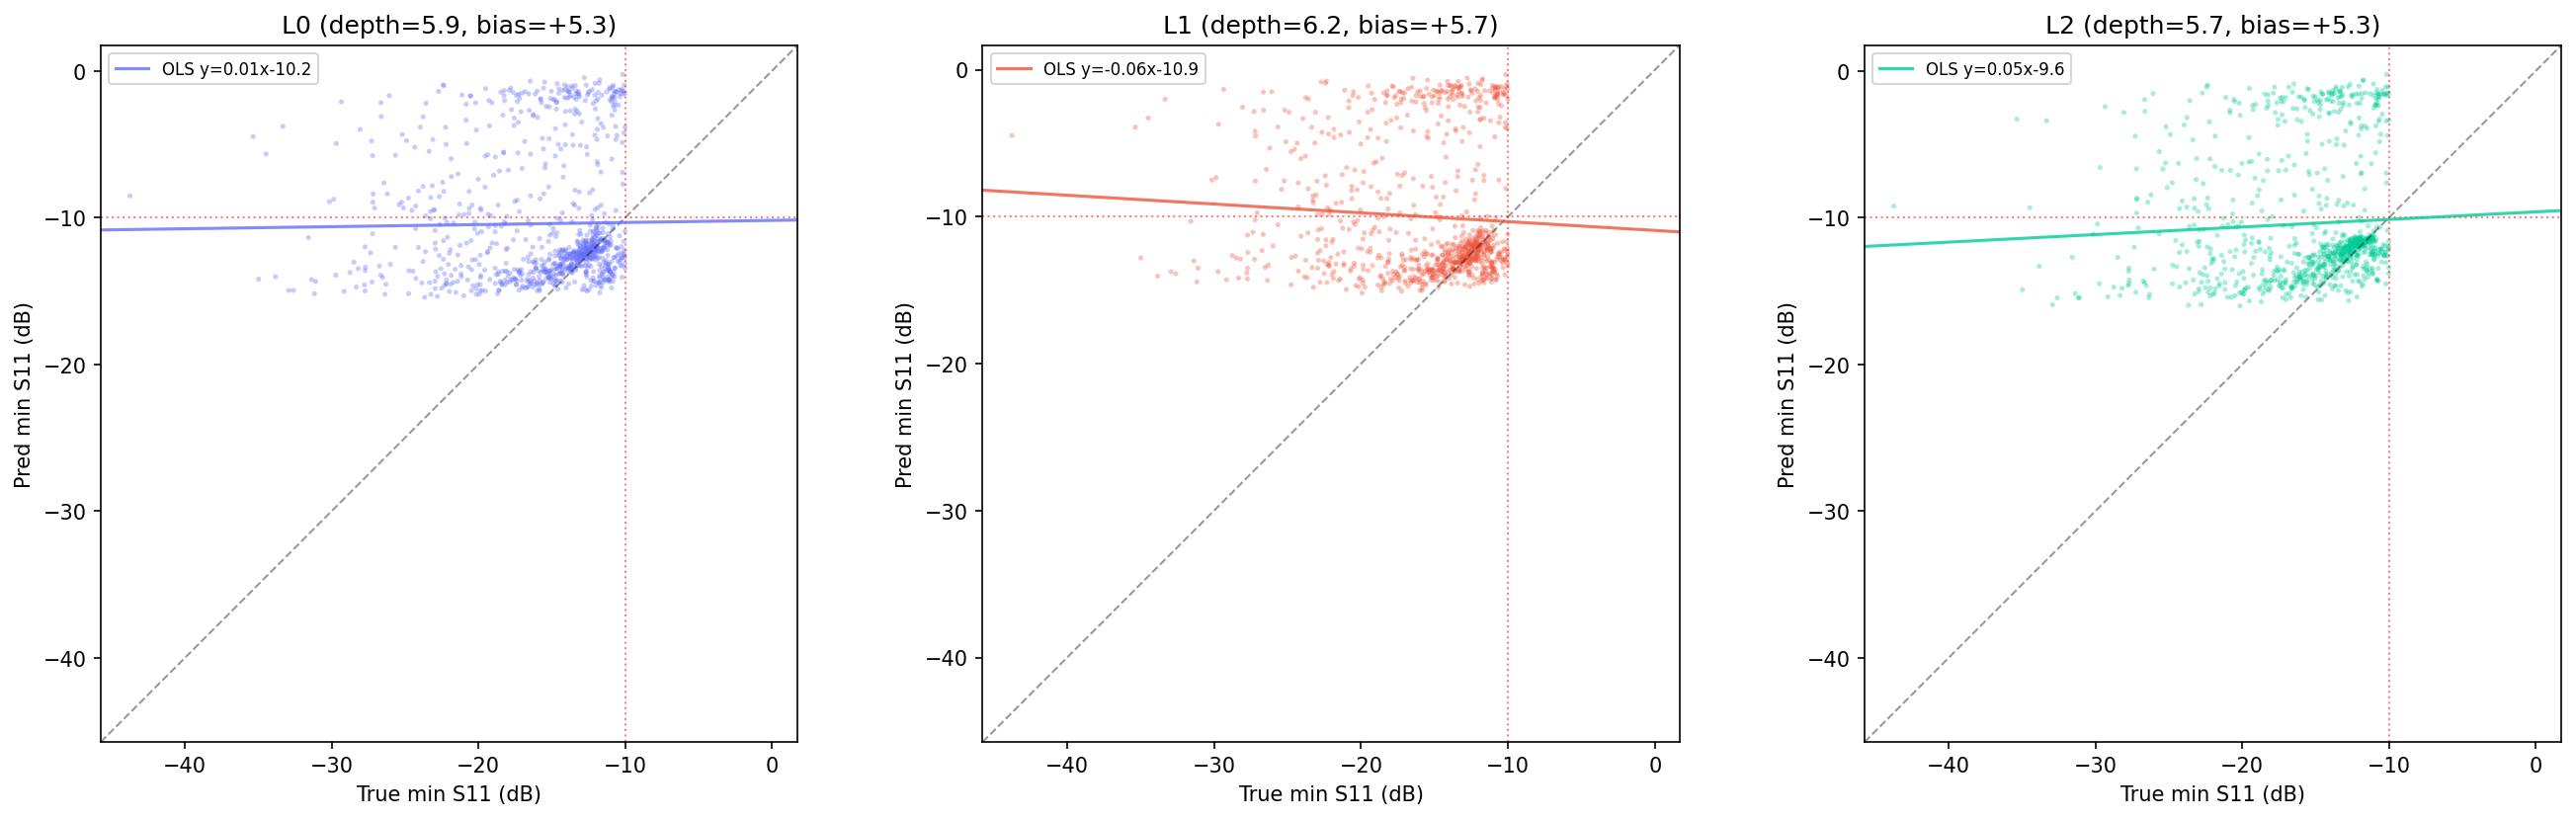

✓ Saved ch22_scatter_arms.png


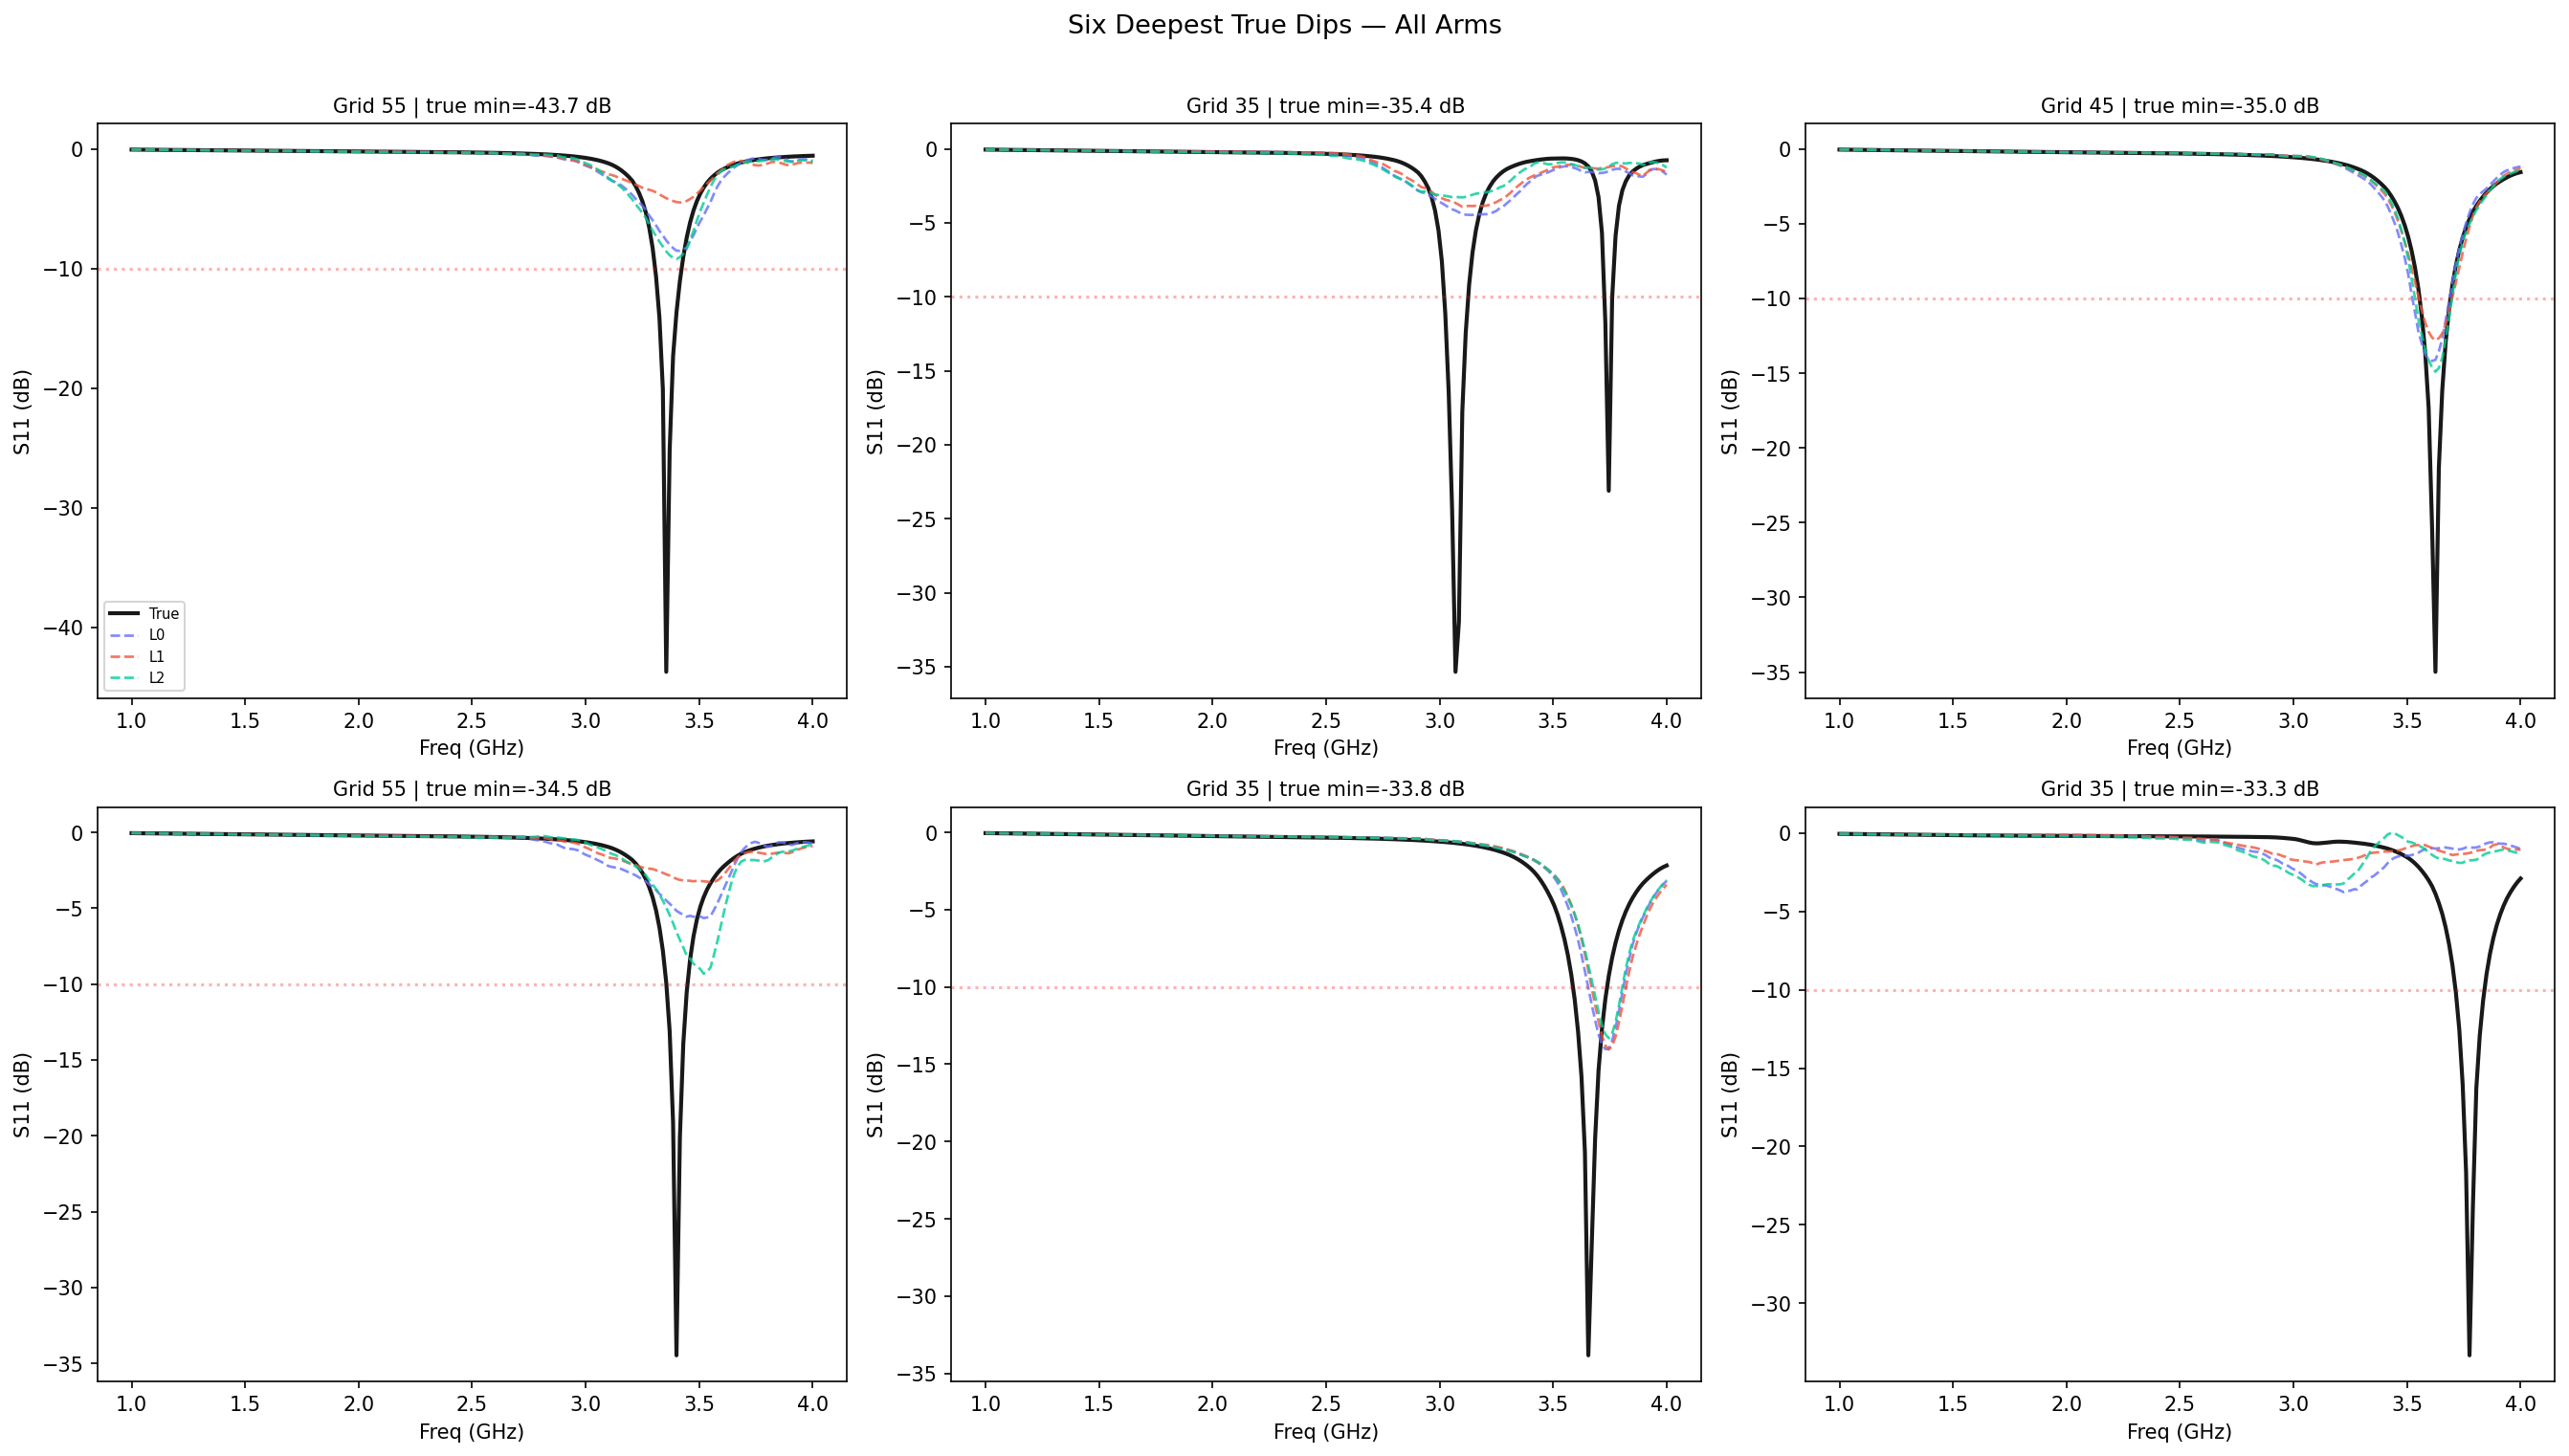

✓ Saved ch22_deep_dip_spectra.png


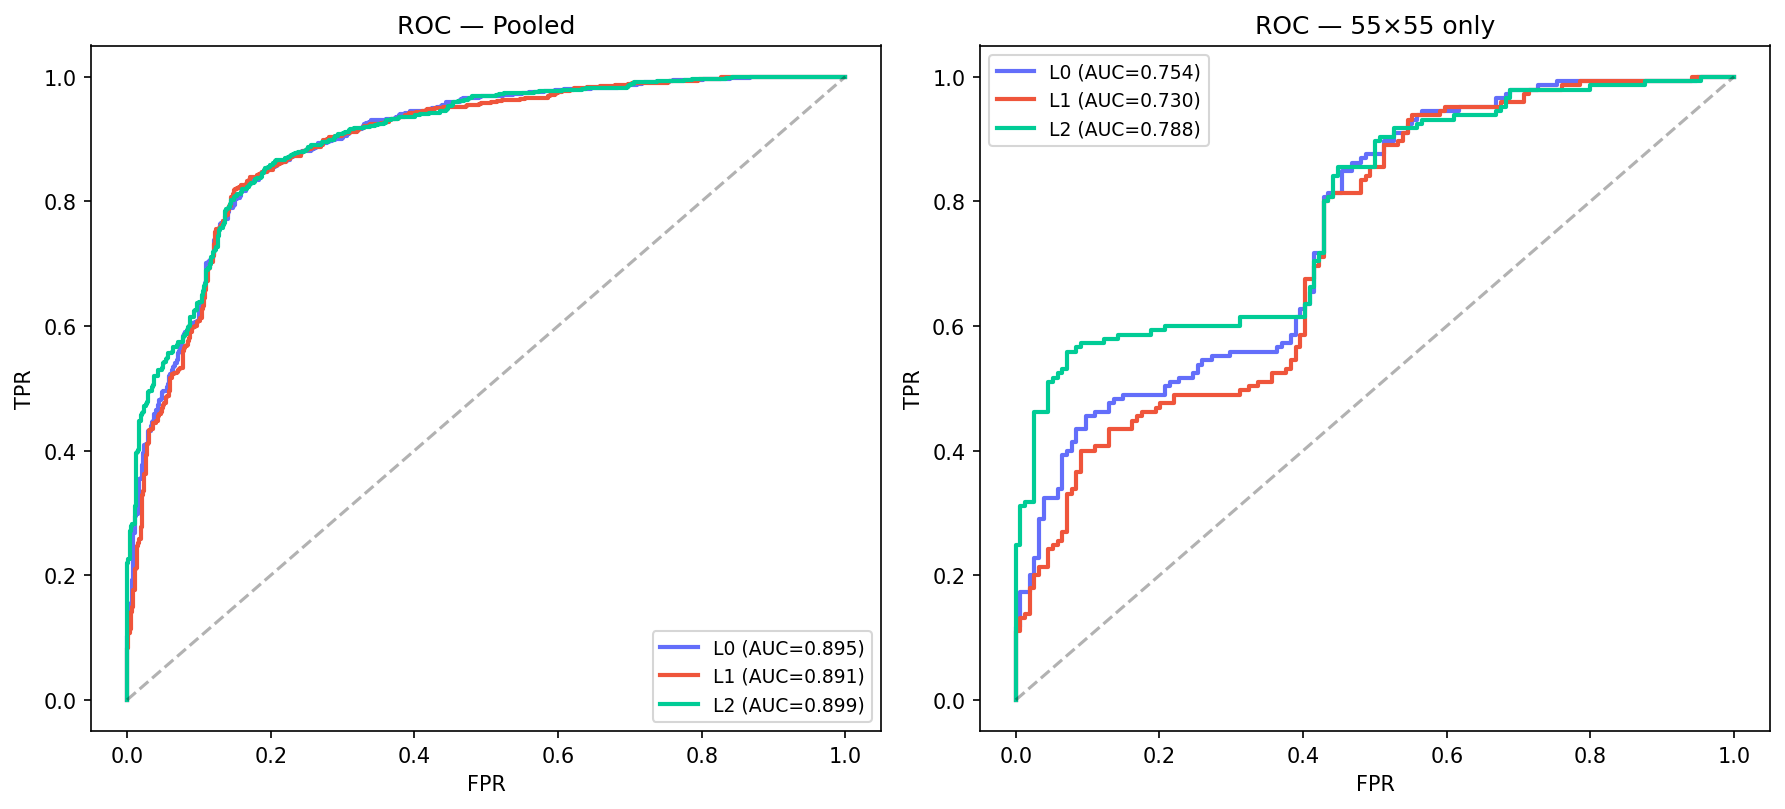

✓ Saved ch22_roc_arms.png


In [9]:
# ==========================================================================
# CELL F — Figures
# ==========================================================================

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150

arm_colors = {'L0': '#636efa', 'L1': '#ef553b', 'L2': '#00cc96', 'L3': '#ab63fa'}

# ─────────────────────────────────────────────────
# Figure 1: Predicted vs True Minimum Scatter
# ─────────────────────────────────────────────────
n_arms = len(stage1_arms)
fig, axes = plt.subplots(1, n_arms, figsize=(6 * n_arms, 5.5))
if n_arms == 1:
    axes = [axes]

for ax_idx, arm_name in enumerate(stage1_arms):
    ax = axes[ax_idx]
    df_arm = eval_results[arm_name]['_df']
    func = df_arm[df_arm['is_functioning']]
    x = func['true_min_db'].values
    y = func['pred_min_db'].values

    ax.scatter(x, y, s=6, alpha=0.35, c=arm_colors[arm_name], edgecolors='none')

    lims = [min(x.min(), y.min()) - 2, max(x.max(), y.max()) + 2]
    ax.plot(lims, lims, 'k--', alpha=0.4, lw=1)
    ax.axhline(-10, color='red', ls=':', alpha=0.5, lw=1)
    ax.axvline(-10, color='red', ls=':', alpha=0.5, lw=1)

    # OLS fit
    slope, intercept, r_val, _, _ = scipy_stats.linregress(x, y)
    x_fit = np.linspace(lims[0], lims[1], 100)
    ax.plot(x_fit, slope * x_fit + intercept,
            color=arm_colors[arm_name], lw=1.5, alpha=0.8,
            label=f'OLS y={slope:.2f}x{intercept:+.1f}')

    depth_err = np.abs(y - x).mean()
    depth_bias = (y - x).mean()
    ax.set_title(f'{arm_name} (depth={depth_err:.1f}, bias={depth_bias:+.1f})')
    ax.set_xlabel('True min S11 (dB)')
    ax.set_ylabel('Pred min S11 (dB)')
    ax.legend(fontsize=8)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect('equal')

plt.tight_layout()
fig.savefig(f'{DATA_ROOT}/figures/ch22_scatter_arms.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'\u2713 Saved ch22_scatter_arms.png')


# ─────────────────────────────────────────────────
# Figure 2: Six deepest-true-dip spectra
# ─────────────────────────────────────────────────
# Use L0's df for selection (all arms share same val samples)
df_ref = eval_results['L0']['_df']
deepest_idx = df_ref.nsmallest(6, 'true_min_db').index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for panel_i, didx in enumerate(deepest_idx):
    ax = axes[panel_i]
    true_curve = eval_results['L0']['_true_curves'][didx]
    ax.plot(freq_axis, true_curve, 'k-', lw=2, label='True', alpha=0.9)

    for arm_name in stage1_arms:
        pred_curve = eval_results[arm_name]['_pred_curves'][didx]
        ax.plot(freq_axis, pred_curve, '--', lw=1.3,
                color=arm_colors[arm_name], label=arm_name, alpha=0.8)

    ax.axhline(-10, color='red', ls=':', alpha=0.3)
    row = df_ref.iloc[didx]
    ax.set_title(f'Grid {row["grid_size"]} | true min={row["true_min_db"]:.1f} dB',
                 fontsize=10)
    ax.set_xlabel('Freq (GHz)')
    ax.set_ylabel('S11 (dB)')
    if panel_i == 0:
        ax.legend(fontsize=7)

plt.suptitle('Six Deepest True Dips — All Arms', fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(f'{DATA_ROOT}/figures/ch22_deep_dip_spectra.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'\u2713 Saved ch22_deep_dip_spectra.png')


# ─────────────────────────────────────────────────
# Figure 3: ROC per arm (pooled + 55x55)
# ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

for ax_idx, (key, title) in enumerate([('pooled', 'Pooled'), (55, '55\u00d755 only')]):
    ax = axes[ax_idx]
    for arm_name in stage1_arms:
        df_arm = eval_results[arm_name]['_df']
        sub = df_arm if key == 'pooled' else df_arm[df_arm['grid_size'] == key]
        labels = sub['is_functioning'].astype(int).values
        scores = -sub['pred_min_db'].values
        if len(np.unique(labels)) > 1:
            fpr, tpr, _ = roc_curve(labels, scores)
            auroc = roc_auc_score(labels, scores)
            ax.plot(fpr, tpr, color=arm_colors[arm_name], lw=2,
                    label=f'{arm_name} (AUC={auroc:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.set_title(f'ROC — {title}')
    ax.legend(fontsize=9)

plt.tight_layout()
fig.savefig(f'{DATA_ROOT}/figures/ch22_roc_arms.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'\u2713 Saved ch22_roc_arms.png')

---
## Cell G — Pre-Registered Selection Rule

**Print the rule before the table.**

- **Primary criterion**: highest pooled validation AUROC.
- **Constraint**: S11 MAE must not degrade by >10% relative to L0.
- **Tie-break**: AUROC within 0.005 → lower depth_error.
- **Secondary**: freq_error must not degrade by >0.005 GHz.

In [10]:
# ==========================================================================
# CELL G — Pre-Registered Selection Rule
# ==========================================================================

# ── PRINT THE RULE FIRST ──
print('=' * 80)
print('PRE-REGISTERED SELECTION RULE')
print('=' * 80)
print("""
Primary criterion: highest pooled validation AUROC.

Constraint: S11 MAE must not degrade by more than 10% relative to arm L0.

Tie-break (AUROC within 0.005): lower depth_error wins.

Secondary report (not a criterion): freq_error must not degrade by more than
0.005 GHz relative to L0. If it does, note this in the verdict.

WINNER:  One arm satisfies the criterion and the constraint.
MIXED:   The AUROC winner violates the S11 constraint, or arms are within
         0.005 AUROC and within 0.2 dB depth of each other. Then run
         Stage 2 (arm L3) and re-apply the rule across all four.
NULL:    No arm improves pooled AUROC over L0 by more than 0.005 AND no arm
         improves depth_error by more than 0.3 dB. Then the loss is not the
         binding constraint at this budget.
""")

# ── THEN THE TABLE ──
print('\n' + '-' * 80)
print('DECIDING NUMBERS')
print('-' * 80)

l0_mae = eval_results['L0']['pooled_s11_mae']
l0_auroc = eval_results['L0']['pooled_auroc']
l0_depth = eval_results['L0']['pooled_depth_error']
l0_freq = eval_results['L0'].get('common_freq_error', float('nan'))

print(f'  L0 reference: S11 MAE={l0_mae:.4f}, AUROC={l0_auroc:.4f}, '
      f'depth={l0_depth:.2f}, freq={l0_freq:.4f}')

print(f'\n{"Arm":<6} {"AUROC":<8} {"S11 MAE":<10} {"MAE %chg":<10} '
      f'{"Depth":<8} {"\u0394depth":<8} {"Freq":<8} {"\u0394freq":<8} {"Status"}')
print('-' * 75)

candidates = []  # arms that pass the constraint

for arm_name in stage1_arms:
    r = eval_results[arm_name]
    auroc = r['pooled_auroc']
    mae = r['pooled_s11_mae']
    depth = r['pooled_depth_error']
    freq = r.get('common_freq_error', float('nan'))

    mae_pct_chg = (mae - l0_mae) / l0_mae * 100 if l0_mae > 0 else 0
    delta_depth = depth - l0_depth
    delta_freq = freq - l0_freq if np.isfinite(l0_freq) and np.isfinite(freq) else float('nan')

    # Constraint: S11 MAE must not degrade by > 10%
    passes = mae_pct_chg <= 10.0
    status = '\u2713' if passes else '\u2717 MAE+{:.1f}%'.format(mae_pct_chg)

    print(f'{arm_name:<6} {auroc:<8.4f} {mae:<10.4f} {mae_pct_chg:<+10.1f} '
          f'{depth:<8.2f} {delta_depth:<+8.2f} {freq:<8.4f} '
          f'{delta_freq if np.isfinite(delta_freq) else float("nan"):<+8.4f} {status}')

    if passes:
        candidates.append((arm_name, auroc, depth, freq))

# ── THEN THE VERDICT ──
print('\n' + '=' * 80)
print('VERDICT')
print('=' * 80)

if not candidates:
    branch = 'NULL'
    print(f'\n  Branch: {branch}')
    print(f'  No arm passes the S11 MAE constraint.')
else:
    # Sort by AUROC descending
    candidates.sort(key=lambda x: (-x[1], x[2]))  # -AUROC, then depth asc

    best_name, best_auroc, best_depth, best_freq = candidates[0]
    auroc_improvement = best_auroc - l0_auroc
    depth_improvement = l0_depth - best_depth

    # Check NULL condition
    any_auroc_improvement = any(
        c[1] - l0_auroc > 0.005 for c in candidates if c[0] != 'L0')
    any_depth_improvement = any(
        l0_depth - c[2] > 0.3 for c in candidates if c[0] != 'L0')

    if not any_auroc_improvement and not any_depth_improvement:
        branch = 'NULL'
        print(f'\n  Branch: {branch}')
        print(f'  No arm improves pooled AUROC over L0 by > 0.005 AND no arm')
        print(f'  improves depth_error by > 0.3 dB.')
        print(f'  The loss is not the binding constraint at this budget.')
        print(f'  This is a publishable negative result, not a failure: the depth')
        print(f'  limitation survived a direct three-way test.')
        print(f'  Recommended next notebook: chunk23_* (architecture)')
    else:
        # Check MIXED condition
        # Are candidates within 0.005 AUROC and within 0.2 dB depth of each other?
        non_l0_candidates = [c for c in candidates if c[0] != 'L0']
        auroc_range = max(c[1] for c in candidates) - min(c[1] for c in candidates)
        depth_range = max(c[2] for c in candidates) - min(c[2] for c in candidates)

        # Does the AUROC winner violate the S11 constraint?
        # Already handled by candidates filtering, but check for MIXED explicitly:
        winner_mae = eval_results[best_name]['pooled_s11_mae']
        winner_violates = (winner_mae - l0_mae) / l0_mae * 100 > 10.0

        if winner_violates or (auroc_range <= 0.005 and depth_range <= 0.2):
            branch = 'MIXED'
            print(f'\n  Branch: {branch}')
            if winner_violates:
                print(f'  AUROC winner ({best_name}) violates S11 MAE constraint.')
            else:
                print(f'  Arms within 0.005 AUROC ({auroc_range:.4f}) and '
                      f'0.2 dB depth ({depth_range:.2f}).')
            print(f'  \u2192 Run Stage 2 (arm L3) and re-apply the rule across all four.')
            print(f'  Recommended: re-run Cell D with L3 added, then re-run Cells E-G.')
        else:
            branch = 'WINNER'
            print(f'\n  Branch: {branch}')
            print(f'  Winner: {best_name}')
            print(f'  AUROC: {best_auroc:.4f} (L0: {l0_auroc:.4f}, '
                  f'\u0394={auroc_improvement:+.4f})')
            print(f'  Depth: {best_depth:.2f} dB (L0: {l0_depth:.2f} dB)')

    # Secondary: freq_error check
    if np.isfinite(l0_freq):
        for arm_name in stage1_arms:
            arm_freq = eval_results[arm_name].get('common_freq_error', float('nan'))
            if np.isfinite(arm_freq) and arm_freq - l0_freq > 0.005:
                print(f'\n  \u26a0 freq_error note: {arm_name} freq_error '
                      f'({arm_freq:.4f}) degrades by {arm_freq - l0_freq:+.4f} GHz '
                      f'> 0.005 vs L0 ({l0_freq:.4f})')

print(f'\n  Branch fired: {branch}')

PRE-REGISTERED SELECTION RULE

Primary criterion: highest pooled validation AUROC.

Constraint: S11 MAE must not degrade by more than 10% relative to arm L0.

Tie-break (AUROC within 0.005): lower depth_error wins.

Secondary report (not a criterion): freq_error must not degrade by more than
0.005 GHz relative to L0. If it does, note this in the verdict.

WINNER:  One arm satisfies the criterion and the constraint.
MIXED:   The AUROC winner violates the S11 constraint, or arms are within
         0.005 AUROC and within 0.2 dB depth of each other. Then run
         Stage 2 (arm L3) and re-apply the rule across all four.
NULL:    No arm improves pooled AUROC over L0 by more than 0.005 AND no arm
         improves depth_error by more than 0.3 dB. Then the loss is not the
         binding constraint at this budget.


--------------------------------------------------------------------------------
DECIDING NUMBERS
-----------------------------------------------------------------------------

---
## Cell H — Guards

Assert: identical subset indices across arms; 587,001 params and 4 blocks
each; no arm's best epoch is 0 or max; test split was never loaded.

In [11]:
# ==========================================================================
# CELL H — Guards
# ==========================================================================

print('=' * 80)
print('GUARDS')
print('=' * 80)

# ── (a) All arms trained on identical subset indices ──
# All arms use the same subset_indices list (ch22_subset_2000.json).
# Verify by checking that every arm provenance has the same hash.
hashes = []
for arm_name in stage1_arms:
    prov_path = f'{DATA_ROOT}/checkpoints/ch22_{arm_name}_provenance.json'
    with open(prov_path) as f:
        prov = json.load(f)
    hashes.append(prov['subset_hash'])

assert len(set(hashes)) == 1, \
    f'GUARD (a) FAILED: subset hashes differ: {hashes}'
print(f'\u2713 Guard (a): all arms trained on identical subset (hash {hashes[0][:16]}...)')

# ── (b) All arms have 587,001 params and len(model.blocks) == 4 ──
for arm_name in stage1_arms:
    ckpt = torch.load(f'{DATA_ROOT}/checkpoints/ch22_{arm_name}.pt',
                       map_location='cpu', weights_only=False)
    model = AntennaGNN(hidden_dim=128, heads=8, edge_dim=16,
                       num_blocks=4, output_dim=201)
    model.load_state_dict(ckpt['model_state'], strict=True)

    n_params = sum(p.numel() for p in model.parameters())
    assert n_params == 587_001, \
        f'GUARD (b) FAILED: {arm_name} has {n_params} params'
    assert len(model.blocks) == 4, \
        f'GUARD (b) FAILED: {arm_name} has {len(model.blocks)} blocks'
    for i, block_pair in enumerate(model.blocks):
        assert len(block_pair) == 2, \
            f'GUARD (b) FAILED: {arm_name} block {i} has {len(block_pair)} sub-blocks'
    del model, ckpt

print(f'\u2713 Guard (b): all arms have 587,001 params and 4 blocks x 2 sub-blocks')

# ── (c) No arm's best epoch is 0 or max ──
max_epochs = 60
for arm_name in stage1_arms:
    r = arm_results[arm_name]
    best_ep = r['best_epoch']
    epochs_run = r['epochs_run']
    assert best_ep > 0, \
        f'GUARD (c) FAILED: {arm_name} best_epoch = 0 (diverged immediately)'
    assert best_ep < max_epochs, \
        f'GUARD (c) FAILED: {arm_name} best_epoch = {best_ep} = max_epochs '\
        f'(early stopping never triggered, comparison is truncated)'
    # Also check that we didn't run to max without stopping
    assert epochs_run < max_epochs, \
        f'GUARD (c) FAILED: {arm_name} ran {epochs_run} = max_epochs '\
        f'(early stopping never triggered)'

print(f'\u2713 Guard (c): no arm diverged immediately or ran to max epochs')
for arm_name in stage1_arms:
    r = arm_results[arm_name]
    print(f'  {arm_name}: best_epoch={r["best_epoch"]}, epochs_run={r["epochs_run"]}')

# ── (d) Test split was never loaded ──
assert not TEST_INDICES_LOADED, \
    'GUARD (d) FAILED: test indices were loaded in this notebook'
print(f'\u2713 Guard (d): test split was never loaded')

print('\n' + '=' * 80)
print('ALL GUARDS PASSED \u2713')
print('=' * 80)

GUARDS
✓ Guard (a): all arms trained on identical subset (hash 2bd670ddd6b55a20...)
✓ Guard (b): all arms have 587,001 params and 4 blocks x 2 sub-blocks
✓ Guard (c): no arm diverged immediately or ran to max epochs
  L0: best_epoch=10, epochs_run=20
  L1: best_epoch=18, epochs_run=28
  L2: best_epoch=16, epochs_run=26
✓ Guard (d): test split was never loaded

ALL GUARDS PASSED ✓


---
## Cell I — Depth-Stratified Classification Diagnostic

**Purpose:** Cell E's pooled/per-grid AUROC hides how accuracy behaves as a
function of true dip depth. The six-deepest-dip spectra plot (Cell F)
suggests systematic false negatives on the strongest resonators. This cell
tests whether that is a small tail or a sizable failure mode, before any
test-set touch is spent.

**Self-contained:** reloads checkpoints from disk rather than relying on
in-memory state, so this cell can be re-run independently of Cells A–H.

**What it does NOT do:** it does not retrain anything or select a different
Stage 1 winner — Cell G's WINNER verdict stands as the loss-selection
decision. This cell only answers whether that winner is safe to carry into
Chunk 24, or whether the deep-resonance blind spot needs a follow-up
before the test touch is spent.

**Depth bins (among functioning samples, i.e. true\_min\_db < −10):**
  - (−15, −10]: shallow dips
  - (−20, −15]: moderate
  - (−30, −20]: deep
  - (−∞, −30]: very deep

**Key metric:** false-negative rate = fraction of truly functioning
samples whose predicted min S11 is ≥ −10 dB (model calls a true resonance
"non-functioning").


✓ Loaded L0 from /content/drive/MyDrive/antenna_gnn/checkpoints/ch22_L0.pt
✓ Loaded L2 from /content/drive/MyDrive/antenna_gnn/checkpoints/ch22_L2.pt
Device: cuda


Inference L0:   0%|          | 0/47 [00:00<?, ?it/s]

✓ L0: 1496 samples -> /content/drive/MyDrive/antenna_gnn/artifacts/ch22_L0_persample_val.csv


Inference L2:   0%|          | 0/47 [00:00<?, ?it/s]

✓ L2: 1496 samples -> /content/drive/MyDrive/antenna_gnn/artifacts/ch22_L2_persample_val.csv
✓ test_idx ordering identical across L0 and L2

DEPTH-STRATIFIED BREAKDOWN — ARM L0
Total functioning: 917 / 1496

  Grid          Bin     n      FNR   Mean Err
---------------------------------------------
 35x35   (-inf,-30]     7    0.286     +21.23
  ⚠ WARNING: L0 / 35x35 / (-inf,-30]: FNR=0.286 >= 0.15 (n=7)
 35x35    (-30,-20]    64    0.312     +12.77
  ⚠ WARNING: L0 / 35x35 / (-30,-20]: FNR=0.312 >= 0.15 (n=64)
 35x35    (-20,-15]    90    0.311      +6.53
  ⚠ WARNING: L0 / 35x35 / (-20,-15]: FNR=0.311 >= 0.15 (n=90)
 35x35    (-15,-10]   155    0.348      +3.28
  ⚠ WARNING: L0 / 35x35 / (-15,-10]: FNR=0.348 >= 0.15 (n=155)
 45x45   (-inf,-30]     4    0.250     +19.85
  ⚠ WARNING: L0 / 45x45 / (-inf,-30]: FNR=0.250 >= 0.15 (n=4)
 45x45    (-30,-20]    70    0.429     +13.02
  ⚠ WARNING: L0 / 45x45 / (-30,-20]: FNR=0.429 >= 0.15 (n=70)
 45x45    (-20,-15]    97    0.299      +6.10
  ⚠ W

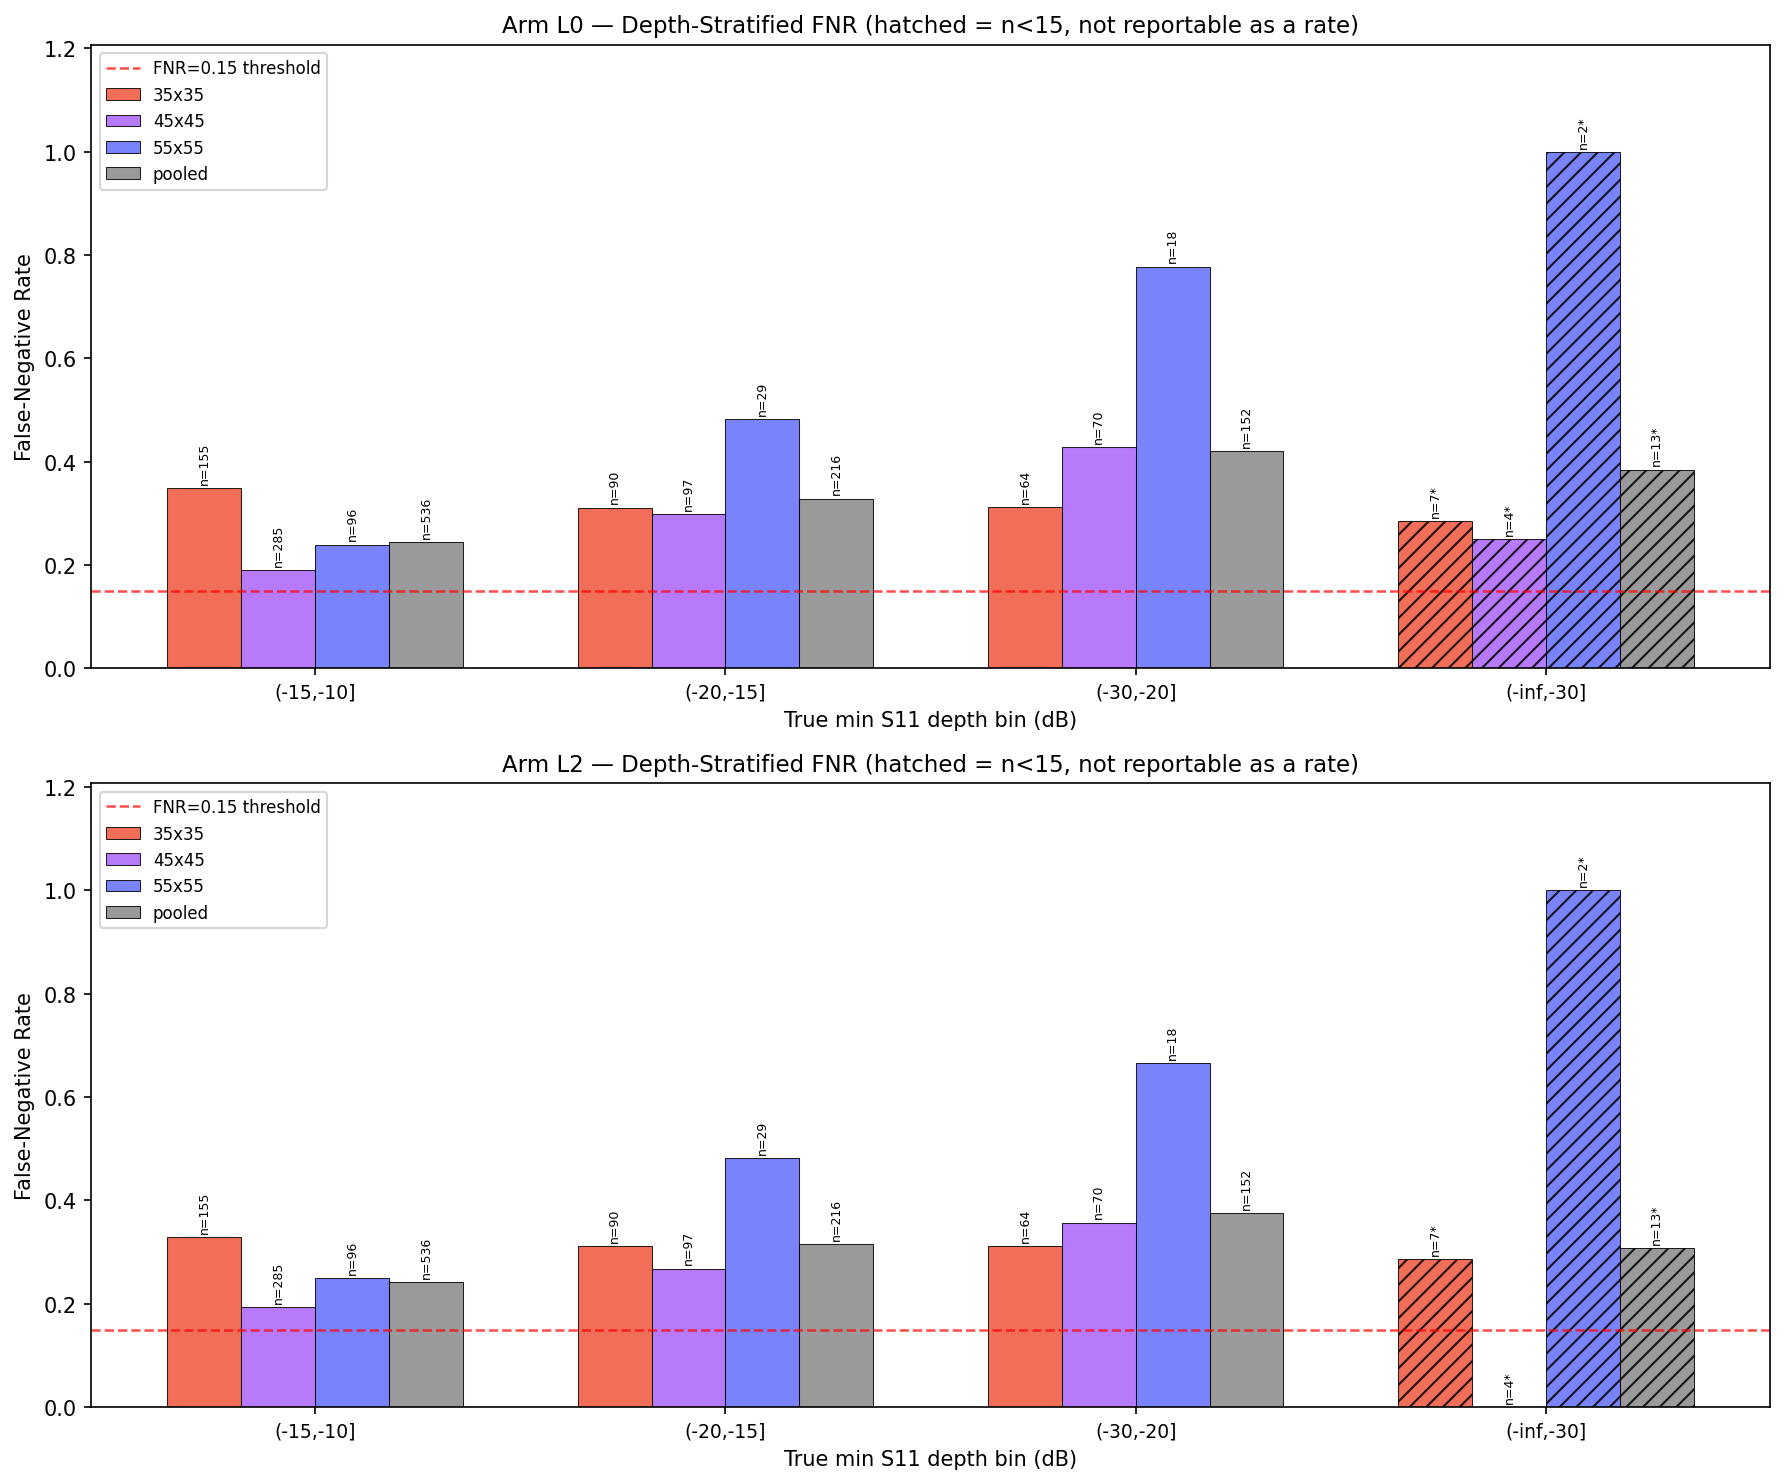

✓ Saved /content/drive/MyDrive/antenna_gnn/figures/ch22_depth_stratified_fnr.png

PRE-REGISTERED VERDICT RULE

For each arm, considering POOLED bins (across all grids):

  PASS:  Every bin with n>=15 has false_negative_rate < 0.15.
         -> "deep-dip failures are within noise of a small tail"

  FAIL:  Any bin with n>=15 has false_negative_rate >= 0.15.
         -> "systematic deep-resonance blind spot"

  INCONCLUSIVE:  Any reported bin has n<15.
         -> "insufficient samples to rule"

L2 is the Cell G winner. This verdict determines whether L2 is safe
to carry into Chunk 24, not whether it is the winner (that is Cell G's
job).

--------------------------------------------------------------------------------
VERDICT NUMBERS
--------------------------------------------------------------------------------

  ARM L0: FAIL
  Insufficient samples in bin (-inf,-30] to rule on this (n=13) — the six-panel plot's apparent failure may or may not generalize; treat as inconclusive, not res

In [12]:
# ==========================================================================
# CELL I — Depth-Stratified Classification Diagnostic
# ==========================================================================

import json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib
from tqdm.notebook import tqdm
from model import AntennaGNN

matplotlib.rcParams['figure.dpi'] = 150

# ── 1. Reload arms L0 and L2 from disk ─────────────────────────────────────
DIAG_ARMS = ['L0', 'L2']
diag_models = {}

for arm_name in DIAG_ARMS:
    ckpt_path = f'{DATA_ROOT}/checkpoints/ch22_{arm_name}.pt'
    ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    model = AntennaGNN(
        hidden_dim=128, heads=8, edge_dim=16,
        num_blocks=4, output_dim=201)
    model.load_state_dict(ckpt['model_state'], strict=True)
    model = model.to(device)
    model.eval()
    diag_models[arm_name] = model
    print(f'\u2713 Loaded {arm_name} from {ckpt_path}')
    del ckpt

print(f'Device: {device}')

# ── 2. One forward pass per arm, build per-sample DataFrames ────────────────
diag_dfs = {}  # {arm_name: pd.DataFrame}

for arm_name in DIAG_ARMS:
    model = diag_models[arm_name]
    records = []
    pos = 0

    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f'Inference {arm_name}',
                          leave=False):
            batch = batch.to(device)
            pred_norm = model(batch)
            pred_db = pred_norm * s11_std_dev + s11_mean_dev
            true_db = batch.y_raw.squeeze(1).to(device)

            pred_np = pred_db.detach().cpu().numpy()
            true_np = true_db.detach().cpu().numpy()

            grids = batch.grid_size
            if isinstance(grids, torch.Tensor):
                grids = grids.tolist()
            is_func_list = batch.is_functioning
            if isinstance(is_func_list, torch.Tensor):
                is_func_list = is_func_list.tolist()

            for i in range(pred_np.shape[0]):
                records.append({
                    'test_idx': pos,
                    'grid': int(grids[i]),
                    'true_min_db': float(true_np[i].min()),
                    'pred_min_db': float(pred_np[i].min()),
                    'is_functioning': bool(is_func_list[i]),
                    'true_argmin_freq': float(
                        freq_axis[np.argmin(true_np[i])]),
                    'pred_argmin_freq': float(
                        freq_axis[np.argmin(pred_np[i])]),
                })
                pos += 1

    df = pd.DataFrame(records)

    # ── Guard: assert exactly 1,496 samples ──
    assert len(df) == 1496, (
        f'{arm_name}: expected 1496 val samples, got {len(df)}')

    # Save to disk so this doesn't need re-deriving
    csv_path = f'{DATA_ROOT}/artifacts/ch22_{arm_name}_persample_val.csv'
    df.to_csv(csv_path, index=False)
    print(f'\u2713 {arm_name}: {len(df)} samples -> {csv_path}')

    diag_dfs[arm_name] = df

# Free GPU memory
for arm_name in DIAG_ARMS:
    del diag_models[arm_name]
del diag_models
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# ── Guard: same test_idx ordering across L0 and L2 ──
assert (diag_dfs['L0']['test_idx'].values ==
        diag_dfs['L2']['test_idx'].values).all(), \
    'test_idx ordering differs between L0 and L2'
print('\u2713 test_idx ordering identical across L0 and L2')

# ── 3. Depth-stratified breakdown ──────────────────────────────────────────
BIN_EDGES = [(-np.inf, -30), (-30, -20), (-20, -15), (-15, -10)]
BIN_LABELS = ['(-inf,-30]', '(-30,-20]', '(-20,-15]', '(-15,-10]']


def assign_bin(val):
    """Assign a true_min_db value to a depth bin label."""
    for (lo, hi), label in zip(BIN_EDGES, BIN_LABELS):
        if lo < val <= hi:
            return label
    return None  # should not happen for is_functioning == True


# Collect all stratified results for the figure
all_strat_results = {}  # {arm_name: list of dicts}

for arm_name in DIAG_ARMS:
    df = diag_dfs[arm_name]
    func_df = df[df['is_functioning']].copy()
    func_df['depth_bin'] = func_df['true_min_db'].apply(assign_bin)

    # ── Guard: bins are non-overlapping and cover all functioning rows ──
    assert func_df['depth_bin'].notna().all(), (
        f'{arm_name}: some functioning rows have no bin assignment')
    n_func = len(func_df)
    n_binned = func_df.groupby('depth_bin')['test_idx'].count().sum()
    assert n_binned == n_func, (
        f'{arm_name}: binned {n_binned} != functioning {n_func} — '
        f'bins are not exhaustive or overlap')

    sep = '=' * 80
    print(f'\n{sep}')
    print(f'DEPTH-STRATIFIED BREAKDOWN — ARM {arm_name}')
    print(sep)
    print(f'Total functioning: {n_func} / {len(df)}')

    header = f'{"Grid":>6} {"Bin":>12} {"n":>5} {"FNR":>8} {"Mean Err":>10}'
    print(f'\n{header}')
    print('-' * len(header))

    arm_strat = []

    for grid_key in [35, 45, 55, 'pooled']:
        if grid_key == 'pooled':
            sub = func_df
            grid_label = 'pooled'
        else:
            sub = func_df[func_df['grid'] == grid_key]
            grid_label = f'{grid_key}x{grid_key}'

        for bin_label in BIN_LABELS:
            bin_sub = sub[sub['depth_bin'] == bin_label]
            n = len(bin_sub)
            if n == 0:
                fnr = float('nan')
                mean_err = float('nan')
            else:
                # False negative = pred_min_db >= -10 for a truly
                # functioning sample
                fn_mask = bin_sub['pred_min_db'] >= -10.0
                fnr = fn_mask.sum() / n
                mean_err = (
                    bin_sub['pred_min_db'] - bin_sub['true_min_db']
                ).mean()

            arm_strat.append({
                'arm': arm_name,
                'grid': grid_label,
                'bin': bin_label,
                'n': n,
                'fnr': fnr,
                'mean_signed_error': mean_err,
            })

            fnr_str = f'{fnr:.3f}' if np.isfinite(fnr) else 'N/A'
            err_str = (
                f'{mean_err:+.2f}' if np.isfinite(mean_err) else 'N/A'
            )
            print(f'{grid_label:>6} {bin_label:>12} {n:>5} '
                  f'{fnr_str:>8} {err_str:>10}')

            # ── Flag bins with FNR >= 0.15 ──
            if np.isfinite(fnr) and fnr >= 0.15:
                print(f'  \u26a0 WARNING: {arm_name} / '
                      f'{grid_label} / {bin_label}: '
                      f'FNR={fnr:.3f} >= 0.15 (n={n})')

    all_strat_results[arm_name] = arm_strat

# ── 4. Figure: depth-stratified false-negative rate ─────────────────────────
# Consistent with Cell F's arm_colors
arm_colors = {
    'L0': '#636efa', 'L1': '#ef553b',
    'L2': '#00cc96', 'L3': '#ab63fa',
}
grid_colors = {35: '#ef553b', 45: '#ab63fa', 55: '#636efa'}
grid_labels_fig = ['35x35', '45x45', '55x55', 'pooled']
grid_keys = [35, 45, 55, 'pooled']

# Order bins from shallow to deep
bin_order = ['(-15,-10]', '(-20,-15]', '(-30,-20]', '(-inf,-30]']

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

for row_idx, arm_name in enumerate(DIAG_ARMS):
    ax = axes[row_idx]
    strat = all_strat_results[arm_name]
    strat_df = pd.DataFrame(strat)

    n_bins = len(bin_order)
    n_groups = len(grid_keys)  # 35, 45, 55, pooled
    bar_width = 0.18
    x_positions = np.arange(n_bins)

    bar_colors_list = [
        grid_colors.get(35, '#ef553b'),
        grid_colors.get(45, '#ab63fa'),
        grid_colors.get(55, '#636efa'),
        '#888888',  # pooled
    ]

    for g_idx, (gk, gl) in enumerate(
            zip(grid_keys, grid_labels_fig)):
        gk_str = gl if gk != 'pooled' else 'pooled'

        heights = []
        ns = []
        hatches = []

        for b_label in bin_order:
            row = strat_df[
                (strat_df['grid'] == gk_str) &
                (strat_df['bin'] == b_label)
            ]
            if len(row) == 0:
                heights.append(0)
                ns.append(0)
                hatches.append('')
            else:
                fnr_val = row['fnr'].values[0]
                n_val = int(row['n'].values[0])
                heights.append(
                    fnr_val if np.isfinite(fnr_val) else 0)
                ns.append(n_val)
                hatches.append('///' if n_val < 15 else '')

        offsets = x_positions + (
            g_idx - n_groups / 2 + 0.5) * bar_width

        bars = ax.bar(
            offsets, heights, bar_width,
            label=gk_str, color=bar_colors_list[g_idx],
            edgecolor='black', linewidth=0.5, alpha=0.85,
        )

        # Apply per-bar hatch for n < 15
        for bar, h in zip(bars, hatches):
            if h:
                bar.set_hatch(h)

        # Annotate n under each bar
        for offset, height, n_val in zip(
                offsets, heights, ns):
            y_text = height + 0.008 if height > 0 else 0.008
            suffix = '*' if n_val < 15 else ''
            ax.text(
                offset, y_text, f'n={n_val}{suffix}',
                ha='center', va='bottom', fontsize=6,
                rotation=90,
            )

    # Reference line at FNR = 0.15
    ax.axhline(
        0.15, color='red', ls='--', lw=1.2,
        alpha=0.7, label='FNR=0.15 threshold',
    )

    ax.set_xticks(x_positions)
    ax.set_xticklabels(bin_order, fontsize=9)
    ax.set_xlabel('True min S11 depth bin (dB)', fontsize=10)
    ax.set_ylabel('False-Negative Rate', fontsize=10)
    ax.set_title(
        f'Arm {arm_name} — Depth-Stratified FNR '
        f'(hatched = n<15, not reportable as a rate)',
        fontsize=11,
    )
    ax.legend(fontsize=8, loc='upper left')
    ax.set_ylim(0, max(0.5, ax.get_ylim()[1] * 1.15))

plt.tight_layout()
fig_path = f'{DATA_ROOT}/figures/ch22_depth_stratified_fnr.png'
fig.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'\u2713 Saved {fig_path}')


# ── 5. Verdict (pre-registered) ────────────────────────────────────────────
print('\n' + '=' * 80)
print('PRE-REGISTERED VERDICT RULE')
print('=' * 80)
print("""
For each arm, considering POOLED bins (across all grids):

  PASS:  Every bin with n>=15 has false_negative_rate < 0.15.
         -> "deep-dip failures are within noise of a small tail"

  FAIL:  Any bin with n>=15 has false_negative_rate >= 0.15.
         -> "systematic deep-resonance blind spot"

  INCONCLUSIVE:  Any reported bin has n<15.
         -> "insufficient samples to rule"

L2 is the Cell G winner. This verdict determines whether L2 is safe
to carry into Chunk 24, not whether it is the winner (that is Cell G's
job).
""")

print('-' * 80)
print('VERDICT NUMBERS')
print('-' * 80)


def evaluate_verdict(arm_name):
    """Evaluate the pre-registered verdict for one arm.

    Returns (verdict_str, detail_lines).
    """
    strat = all_strat_results[arm_name]
    strat_df = pd.DataFrame(strat)
    pooled = strat_df[strat_df['grid'] == 'pooled']

    verdict_lines = []
    has_fail = False
    has_inconclusive = False

    for _, row in pooled.iterrows():
        b = row['bin']
        n = int(row['n'])
        fnr = row['fnr']

        if n < 15:
            has_inconclusive = True
            verdict_lines.append(
                f'  Insufficient samples in bin {b} to rule '
                f'on this (n={n}) — the six-panel plot\'s '
                f'apparent failure may or may not generalize; '
                f'treat as inconclusive, not resolved.'
            )
        elif np.isfinite(fnr) and fnr >= 0.15:
            has_fail = True
            verdict_lines.append(
                f'  {arm_name} has a systematic deep-resonance '
                f'blind spot in bin {b}, pooled '
                f'(rate={fnr:.2f}, n={n}) — do not spend '
                f'the Chunk 24 test touch on this checkpoint '
                f'without addressing it.'
            )
        else:
            verdict_lines.append(
                f'  bin {b}: FNR={fnr:.3f}, n={n} \u2713'
            )

    # Also check per-grid for fail cases
    per_grid = strat_df[strat_df['grid'] != 'pooled']
    for _, row in per_grid.iterrows():
        b = row['bin']
        n = int(row['n'])
        fnr = row['fnr']
        g = row['grid']
        if n >= 15 and np.isfinite(fnr) and fnr >= 0.15:
            has_fail = True
            verdict_lines.append(
                f'  {arm_name} has a systematic deep-resonance '
                f'blind spot in bin {b}, grid {g} '
                f'(rate={fnr:.2f}, n={n}) — do not spend '
                f'the Chunk 24 test touch on this checkpoint '
                f'without addressing it.'
            )

    if has_fail:
        overall = 'FAIL'
    elif has_inconclusive:
        overall = 'INCONCLUSIVE'
    else:
        overall = 'PASS'

    return overall, verdict_lines


# Print both arms side by side
verdicts = {}
for arm_name in DIAG_ARMS:
    overall, lines = evaluate_verdict(arm_name)
    verdicts[arm_name] = overall
    print(f'\n  ARM {arm_name}: {overall}')
    for line in lines:
        print(line)

# Final summary comparison
print('\n' + '=' * 80)
print('SUMMARY')
print('=' * 80)

l2_verdict = verdicts['L2']
l0_verdict = verdicts['L0']

if l2_verdict == 'PASS':
    print("\n  L2's deep-dip failures are within noise of a "
          "small tail — proceed to Chunk 24.")
elif l2_verdict == 'INCONCLUSIVE':
    print("\n  Inconclusive for L2. Some bins have n<15; "
          "the six-panel plot's apparent failure may or "
          "may not generalize.")
else:
    print("\n  L2 has at least one systematic deep-resonance "
          "blind spot — do not spend the Chunk 24 test "
          "touch without addressing it.")

# Comparison with L0
if l0_verdict == l2_verdict:
    print(f"  L0 shows the same verdict ({l0_verdict}) — "
          f"L2 neither improved nor worsened this failure mode.")
elif l2_verdict == 'PASS' and l0_verdict != 'PASS':
    print(f"  L2 ({l2_verdict}) improved over L0 ({l0_verdict}) "
          f"on deep-resonance detection.")
elif l2_verdict != 'PASS' and l0_verdict == 'PASS':
    print(f"  \u26a0 L2 ({l2_verdict}) is WORSE than L0 "
          f"({l0_verdict}) on deep-resonance detection.")
else:
    print(f"  Both arms are {l0_verdict}/{l2_verdict} — "
          f"compare bin-level FNR in the table above.")

print('\n' + '=' * 80)
print('Cell I complete.')
print('=' * 80)


---
## Cell J — Threshold-Recalibration Recheck

**Purpose:** Cell I found FAIL for both L0 and L2 at the fixed −10 dB
boundary, with FNR 24–43% across most of the functioning population. This
cell asks one question only: is that a **calibration problem** (shift the
decision threshold, most of the FNR disappears) or a **ranking problem**
(FNR stays high even at each arm's own optimal threshold)?

**Constraints:**
- No model reload, no dataset reload, no retraining.
- Reads only two kinds of CSV artifacts already on disk:
  - `ch22_{arm}_persample_val.csv` (from Cell I)
  - `ch22_arm_comparison.csv` (from Cell E)
- Fully self-contained: can run in a fresh kernel with only these CSVs
  and `DATA_ROOT` defined.

**Does NOT** change Cell G's WINNER verdict or trigger retraining.


Loaded L0: 1496 rows from /content/drive/MyDrive/antenna_gnn/artifacts/ch22_L0_persample_val.csv
Loaded L2: 1496 rows from /content/drive/MyDrive/antenna_gnn/artifacts/ch22_L2_persample_val.csv
Loaded arm comparison: 4 rows from /content/drive/MyDrive/antenna_gnn/artifacts/ch22_arm_comparison.csv
  L0: tau_star_bal = -6.00 dB
  L2: tau_star_bal = -6.00 dB
Guard: both persample CSVs have 1496 rows

THRESHOLD-RECALIBRATION TABLE — ARM L0 (tau_star_bal = -6.00 dB)

  Grid          Bin     n   FNR@-10  FNR@tau*    delta
------------------------------------------------------
 35x35   (-inf,-30]     7     0.286     0.286   +0.000
 35x35    (-30,-20]    64     0.312     0.188   +0.125
 35x35    (-20,-15]    90     0.311     0.222   +0.089
 35x35    (-15,-10]   155     0.348     0.265   +0.084
 45x45   (-inf,-30]     4     0.250     0.000   +0.250
 45x45    (-30,-20]    70     0.429     0.200   +0.229
 45x45    (-20,-15]    97     0.299     0.206   +0.093
 45x45    (-15,-10]   285     0.189   

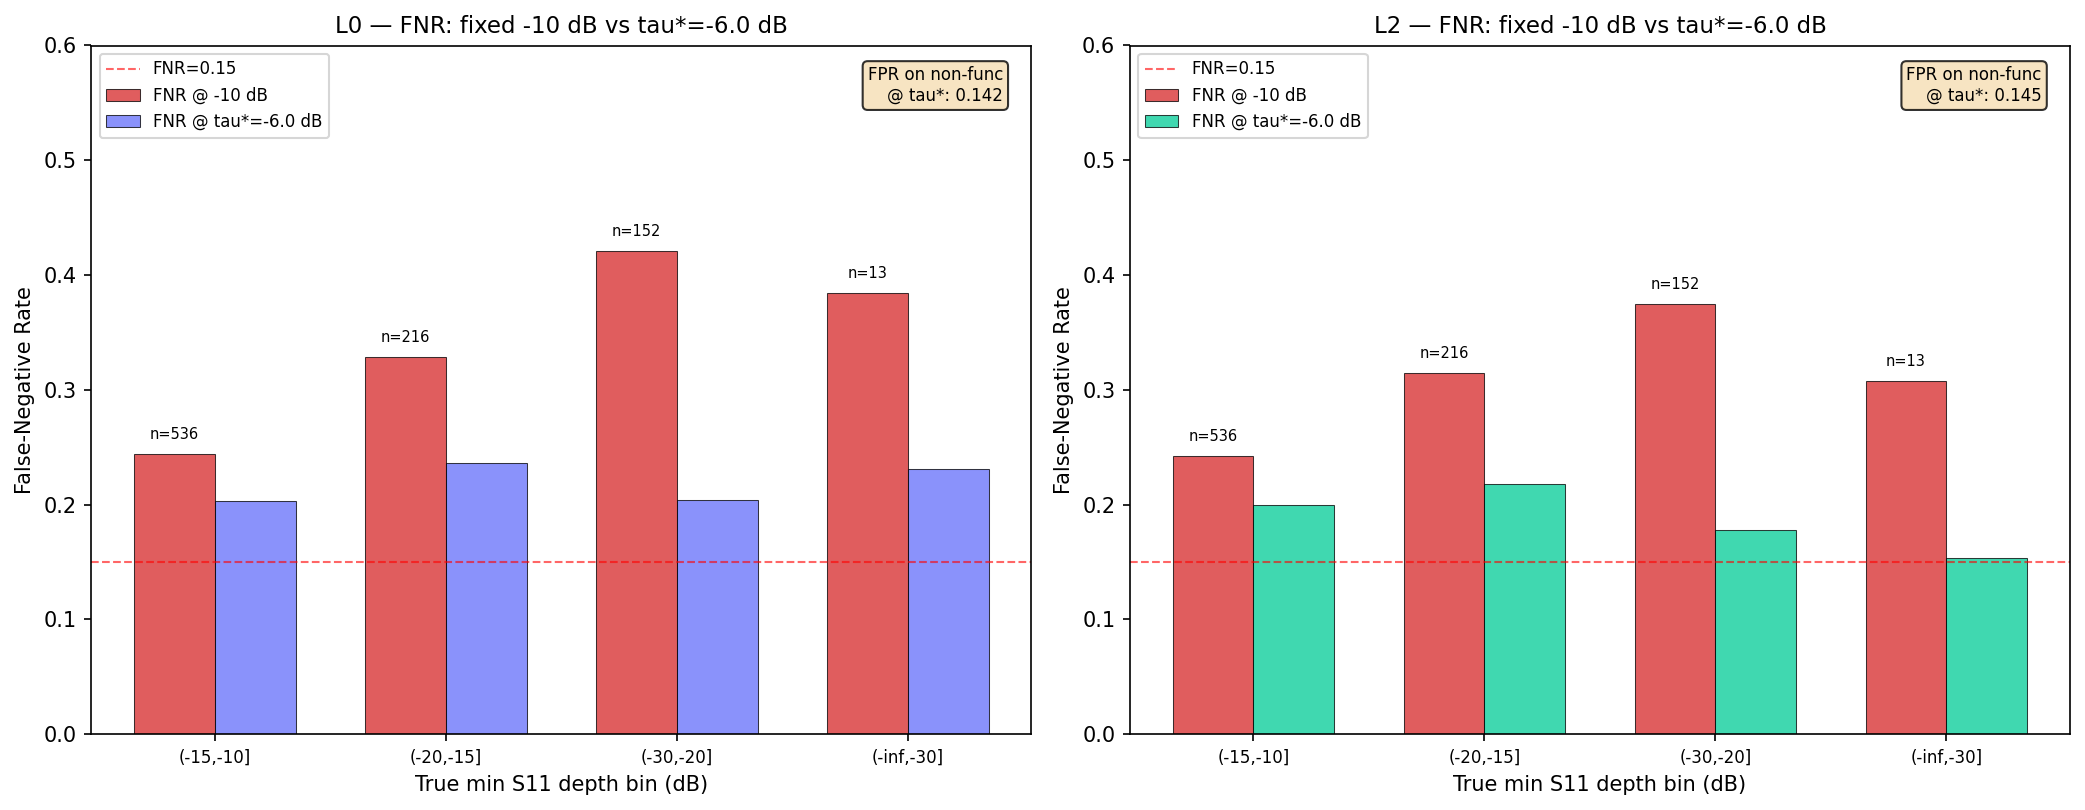

Saved /content/drive/MyDrive/antenna_gnn/figures/ch22_threshold_recheck.png

PRE-REGISTERED VERDICT RULE

Apply Cell I's exact PASS/FAIL/INCONCLUSIVE rule to fnr_own_tau:
  - n >= 15 required for a bin to be reportable
  - FNR < 0.15 = PASS for that bin

If verdict flips to PASS at tau_star_bal:
  -> CALIBRATION STORY: recall recovers with the arm's own optimal threshold.

If verdict is still FAIL at tau_star_bal:
  -> RANKING PROBLEM: the model does not separate these cases at any threshold.

If mixed across bins:
  -> Report per-bin outcomes explicitly.

------------------------------------------------------------------------------------------
VERDICT NUMBERS
------------------------------------------------------------------------------------------

  ARM L0 (tau* = -6.00 dB):
             Bin     n   FNR@-10   stat  FNR@tau*   stat
    -------------------------------------------------------
      (-inf,-30]    13     0.385 INCONCLUSIVE     0.231 INCONCLUSIVE
       (-30,-20]   152  

In [13]:
# ==========================================================================
# CELL J — Threshold-Recalibration Recheck
# ==========================================================================
# Self-contained: reads only CSV artifacts from prior cells.
# No model reload, no dataset reload, no retraining.

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150

ARMS = ['L0', 'L2']

# ── 1. Load per-sample CSVs (from Cell I) ──────────────────────────────────
persample = {}
for arm in ARMS:
    csv_path = f'{DATA_ROOT}/artifacts/ch22_{arm}_persample_val.csv'
    if not os.path.exists(csv_path):
        raise FileNotFoundError(
            f'{csv_path} not found. Run Cell I first to produce it.')
    persample[arm] = pd.read_csv(csv_path)
    print(f'Loaded {arm}: {len(persample[arm])} rows from {csv_path}')

# Load arm comparison CSV (from Cell E) for tau_star_bal
comp_path = f'{DATA_ROOT}/artifacts/ch22_arm_comparison.csv'
if not os.path.exists(comp_path):
    raise FileNotFoundError(
        f'{comp_path} not found. Run Cell E first to produce it.')
comp_df = pd.read_csv(comp_path)
print(f'Loaded arm comparison: {len(comp_df)} rows from {comp_path}')

# Extract tau_star_bal per arm
tau_star = {}
for arm in ARMS:
    row = comp_df[comp_df['arm'] == arm]
    assert len(row) == 1, (
        f'Expected exactly 1 row for {arm} in ch22_arm_comparison.csv, '
        f'got {len(row)}')
    val = row['tau_star_bal'].values[0]
    assert not np.isnan(val), (
        f'tau_star_bal for {arm} is NaN in ch22_arm_comparison.csv')
    tau_star[arm] = float(val)
    print(f'  {arm}: tau_star_bal = {tau_star[arm]:.2f} dB')

# ── 7a. Guard: both CSVs have exactly 1496 rows ───────────────────────────
for arm in ARMS:
    n = len(persample[arm])
    assert n == 1496, (
        f'{arm} persample CSV has {n} rows, expected 1496')
print('Guard: both persample CSVs have 1496 rows')

# ── 2. Reproduce Cell I's exact bin definitions ───────────────────────────
BIN_EDGES = [(-np.inf, -30), (-30, -20), (-20, -15), (-15, -10)]
BIN_LABELS = ['(-inf,-30]', '(-30,-20]', '(-20,-15]', '(-15,-10]']


def assign_bin(val):
    """Assign a true_min_db value to a depth bin label."""
    for (lo, hi), label in zip(BIN_EDGES, BIN_LABELS):
        if lo < val <= hi:
            return label
    return None


# ── 3. Depth-stratified FNR at both thresholds ────────────────────────────
all_results = {}  # {arm: list of dicts}

for arm in ARMS:
    df = persample[arm].copy()
    func_df = df[df['is_functioning']].copy()
    func_df['depth_bin'] = func_df['true_min_db'].apply(assign_bin)

    # Guard: all functioning rows assigned a bin
    assert func_df['depth_bin'].notna().all(), (
        f'{arm}: some functioning rows have no bin assignment')

    tau = tau_star[arm]

    sep = '=' * 90
    print(f'\n{sep}')
    print(f'THRESHOLD-RECALIBRATION TABLE — ARM {arm} '
          f'(tau_star_bal = {tau:.2f} dB)')
    print(sep)

    header = (f'{"Grid":>6} {"Bin":>12} {"n":>5} '
              f'{"FNR@-10":>9} {"FNR@tau*":>9} {"delta":>8}')
    print(f'\n{header}')
    print('-' * len(header))

    arm_results = []

    for grid_key in [35, 45, 55, 'pooled']:
        if grid_key == 'pooled':
            sub = func_df
            grid_label = 'pooled'
        else:
            sub = func_df[func_df['grid'] == grid_key]
            grid_label = f'{grid_key}x{grid_key}'

        for bin_label in BIN_LABELS:
            bin_sub = sub[sub['depth_bin'] == bin_label]
            n = len(bin_sub)
            if n == 0:
                fnr_10 = float('nan')
                fnr_tau = float('nan')
            else:
                fnr_10 = (bin_sub['pred_min_db'] >= -10.0).sum() / n
                fnr_tau = (bin_sub['pred_min_db'] >= tau).sum() / n

            delta = fnr_10 - fnr_tau if (
                np.isfinite(fnr_10) and np.isfinite(fnr_tau)
            ) else float('nan')

            arm_results.append({
                'arm': arm,
                'grid': grid_label,
                'bin': bin_label,
                'n': n,
                'fnr_fixed10': fnr_10,
                'fnr_own_tau': fnr_tau,
                'delta': delta,
            })

            f10 = f'{fnr_10:.3f}' if np.isfinite(fnr_10) else 'N/A'
            ft = f'{fnr_tau:.3f}' if np.isfinite(fnr_tau) else 'N/A'
            d = f'{delta:+.3f}' if np.isfinite(delta) else 'N/A'
            print(f'{grid_label:>6} {bin_label:>12} {n:>5} '
                  f'{f10:>9} {ft:>9} {d:>8}')

    all_results[arm] = arm_results

# ── 7b. Drift guard: recomputed fnr_fixed10 for pooled (-15,-10] must ──
#    match Cell I's value to within 1e-6
print('\n' + '-' * 90)
print('DRIFT GUARD: Cell I consistency check')
print('-' * 90)

for arm in ARMS:
    arm_df = pd.DataFrame(all_results[arm])
    pooled_shallow = arm_df[
        (arm_df['grid'] == 'pooled') &
        (arm_df['bin'] == '(-15,-10]')
    ]
    assert len(pooled_shallow) == 1
    recomputed = pooled_shallow['fnr_fixed10'].values[0]

    # Recompute from the raw CSV as an independent check
    df = persample[arm]
    func_df = df[df['is_functioning']].copy()
    func_df['depth_bin'] = func_df['true_min_db'].apply(assign_bin)
    shallow = func_df[func_df['depth_bin'] == '(-15,-10]']
    n = len(shallow)
    independent = (shallow['pred_min_db'] >= -10.0).sum() / n if n > 0 else float('nan')

    assert abs(recomputed - independent) < 1e-6, (
        f'{arm} pooled (-15,-10] FNR mismatch: '
        f'table={recomputed:.6f} vs independent={independent:.6f}')

    print(f'  {arm} pooled (-15,-10] FNR@-10 = {recomputed:.6f} '
          f'(matches independent recomputation)')

print('Drift guard passed')


# ── 4. Companion check: FPR on non-functioning at tau_star_bal ─────────────
print('\n' + '=' * 90)
print('COMPANION CHECK: False-Positive Rate on non-functioning antennas')
print('=' * 90)

fpr_at_tau = {}
for arm in ARMS:
    df = persample[arm]
    nonfunc = df[~df['is_functioning']]
    n_nf = len(nonfunc)
    if n_nf == 0:
        fpr = float('nan')
    else:
        fpr = (nonfunc['pred_min_db'] < tau_star[arm]).sum() / n_nf
    fpr_at_tau[arm] = fpr
    print(f'  {arm}: among {n_nf} non-functioning samples, '
          f'FPR at tau*={tau_star[arm]:.2f} dB = {fpr:.3f} '
          f'({(nonfunc["pred_min_db"] < tau_star[arm]).sum()} '
          f'false positives)')


# ── 5. Figure ──────────────────────────────────────────────────────────────
bin_order = ['(-15,-10]', '(-20,-15]', '(-30,-20]', '(-inf,-30]']

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

arm_colors = {'L0': '#636efa', 'L2': '#00cc96'}

for ax_idx, arm in enumerate(ARMS):
    ax = axes[ax_idx]
    arm_df = pd.DataFrame(all_results[arm])
    pooled = arm_df[arm_df['grid'] == 'pooled']

    x = np.arange(len(bin_order))
    bar_w = 0.35

    h_fixed = []
    h_tau = []
    ns = []
    for b in bin_order:
        row = pooled[pooled['bin'] == b]
        if len(row) == 0:
            h_fixed.append(0)
            h_tau.append(0)
            ns.append(0)
        else:
            f10 = row['fnr_fixed10'].values[0]
            ft = row['fnr_own_tau'].values[0]
            h_fixed.append(f10 if np.isfinite(f10) else 0)
            h_tau.append(ft if np.isfinite(ft) else 0)
            ns.append(int(row['n'].values[0]))

    bars1 = ax.bar(
        x - bar_w / 2, h_fixed, bar_w,
        label='FNR @ -10 dB', color='#d62728', alpha=0.75,
        edgecolor='black', linewidth=0.5)
    bars2 = ax.bar(
        x + bar_w / 2, h_tau, bar_w,
        label=f'FNR @ tau*={tau_star[arm]:.1f} dB',
        color=arm_colors[arm], alpha=0.75,
        edgecolor='black', linewidth=0.5)

    # Annotate n on the fixed-threshold bars
    for xi, n_val in zip(x, ns):
        ax.text(xi - bar_w / 2, h_fixed[x.tolist().index(xi)] + 0.01,
                f'n={n_val}', ha='center', va='bottom', fontsize=7)

    # Reference line
    ax.axhline(0.15, color='red', ls='--', lw=1, alpha=0.6,
               label='FNR=0.15')

    # FPR annotation
    fpr_val = fpr_at_tau[arm]
    ax.text(0.97, 0.97,
            f'FPR on non-func\n@ tau*: {fpr_val:.3f}',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=8, bbox=dict(
                boxstyle='round,pad=0.3', facecolor='wheat',
                alpha=0.8))

    ax.set_xticks(x)
    ax.set_xticklabels(bin_order, fontsize=8)
    ax.set_xlabel('True min S11 depth bin (dB)')
    ax.set_ylabel('False-Negative Rate')
    ax.set_title(f'{arm} — FNR: fixed -10 dB vs tau*={tau_star[arm]:.1f} dB',
                 fontsize=11)
    ax.legend(fontsize=8, loc='upper left')
    ax.set_ylim(0, max(0.6, max(h_fixed + h_tau) * 1.25))

plt.tight_layout()
fig_path = f'{DATA_ROOT}/figures/ch22_threshold_recheck.png'
fig.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved {fig_path}')


# ── 6. Verdict (pre-registered) ───────────────────────────────────────────
print('\n' + '=' * 90)
print('PRE-REGISTERED VERDICT RULE')
print('=' * 90)
print("""
Apply Cell I's exact PASS/FAIL/INCONCLUSIVE rule to fnr_own_tau:
  - n >= 15 required for a bin to be reportable
  - FNR < 0.15 = PASS for that bin

If verdict flips to PASS at tau_star_bal:
  -> CALIBRATION STORY: recall recovers with the arm's own optimal threshold.

If verdict is still FAIL at tau_star_bal:
  -> RANKING PROBLEM: the model does not separate these cases at any threshold.

If mixed across bins:
  -> Report per-bin outcomes explicitly.
""")

print('-' * 90)
print('VERDICT NUMBERS')
print('-' * 90)


def verdict_at_tau(arm):
    """Apply Cell I's verdict rule using fnr_own_tau instead of fnr_fixed10.

    Returns (overall, per_bin_verdicts).
    """
    arm_df = pd.DataFrame(all_results[arm])
    pooled = arm_df[arm_df['grid'] == 'pooled']

    per_bin = []
    has_fail = False
    has_inconclusive = False

    for _, row in pooled.iterrows():
        b = row['bin']
        n = int(row['n'])
        fnr_10 = row['fnr_fixed10']
        fnr_tau = row['fnr_own_tau']

        if n < 15:
            has_inconclusive = True
            per_bin.append({
                'bin': b, 'n': n,
                'fnr_fixed10': fnr_10,
                'fnr_own_tau': fnr_tau,
                'status_fixed': 'INCONCLUSIVE',
                'status_tau': 'INCONCLUSIVE',
            })
        else:
            s_fixed = ('FAIL' if np.isfinite(fnr_10) and fnr_10 >= 0.15
                        else 'PASS')
            s_tau = ('FAIL' if np.isfinite(fnr_tau) and fnr_tau >= 0.15
                      else 'PASS')
            if s_tau == 'FAIL':
                has_fail = True
            per_bin.append({
                'bin': b, 'n': n,
                'fnr_fixed10': fnr_10,
                'fnr_own_tau': fnr_tau,
                'status_fixed': s_fixed,
                'status_tau': s_tau,
            })

    if has_fail:
        overall = 'FAIL'
    elif has_inconclusive:
        overall = 'INCONCLUSIVE'
    else:
        overall = 'PASS'

    return overall, per_bin


for arm in ARMS:
    overall, per_bin = verdict_at_tau(arm)

    print(f'\n  ARM {arm} (tau* = {tau_star[arm]:.2f} dB):')
    print(f'    {"Bin":>12} {"n":>5} {"FNR@-10":>9} {"stat":>6} '
          f'{"FNR@tau*":>9} {"stat":>6}')
    print(f'    ' + '-' * 55)

    any_flipped = False
    any_stayed_fail = False

    for pb in per_bin:
        f10 = (f'{pb["fnr_fixed10"]:.3f}'
               if np.isfinite(pb['fnr_fixed10']) else 'N/A')
        ft = (f'{pb["fnr_own_tau"]:.3f}'
              if np.isfinite(pb['fnr_own_tau']) else 'N/A')
        print(f'    {pb["bin"]:>12} {pb["n"]:>5} '
              f'{f10:>9} {pb["status_fixed"]:>6} '
              f'{ft:>9} {pb["status_tau"]:>6}')
        if (pb['status_fixed'] == 'FAIL' and
                pb['status_tau'] == 'PASS'):
            any_flipped = True
        if pb['status_tau'] == 'FAIL':
            any_stayed_fail = True

    print(f'    Overall at tau*: {overall}')
    print(f'    FPR on non-functioning at tau*: '
          f'{fpr_at_tau[arm]:.3f}')

# ── Final cross-arm verdict ───────────────────────────────────────────────
print('\n' + '=' * 90)
print('FINAL VERDICT')
print('=' * 90)

v_l2, bins_l2 = verdict_at_tau('L2')
v_l0, bins_l0 = verdict_at_tau('L0')

# Check for mixed case: some bins flip, some stay FAIL
l2_flipped = [
    pb for pb in bins_l2
    if pb['status_fixed'] == 'FAIL' and pb['status_tau'] == 'PASS'
]
l2_stayed_fail = [
    pb for pb in bins_l2
    if pb['status_tau'] == 'FAIL' and pb['n'] >= 15
]

if v_l2 == 'PASS':
    print("""
  CALIBRATION STORY -- recall recovers with the arm's own optimal
  threshold. Report class accuracy in Chunk 24 at tau_star_bal
  (with FPR-on-non-functioning cost shown), not a retrain.
""")
    print(f'  L2 FPR on non-functioning at tau*='
          f'{tau_star["L2"]:.2f}: {fpr_at_tau["L2"]:.3f}')
    print(f'  L0 FPR on non-functioning at tau*='
          f'{tau_star["L0"]:.2f}: {fpr_at_tau["L0"]:.3f}')

elif len(l2_flipped) > 0 and len(l2_stayed_fail) > 0:
    # Mixed case
    print('\n  MIXED VERDICT (bin-dependent):')
    for pb in l2_flipped:
        print(f'    bin {pb["bin"]}: FLIPPED to PASS at tau* '
              f'(FNR {pb["fnr_fixed10"]:.3f} -> '
              f'{pb["fnr_own_tau"]:.3f})')
    for pb in l2_stayed_fail:
        print(f'    bin {pb["bin"]}: STILL FAIL at tau* '
              f'(FNR {pb["fnr_own_tau"]:.3f}, n={pb["n"]})')
    print('\n  The verdict is bin-dependent. Some depth ranges '
          'recover with threshold shift, others do not.')
    print('  This is partly calibration, partly ranking. '
          'A threshold-only fix is insufficient.')

else:
    # Pure FAIL
    print("""
  RANKING PROBLEM -- shifting the threshold does not rescue recall
  on functioning antennas. This is not a calibration fix; the model
  does not separate these cases at any single threshold. Chunk 23's
  classification head (trained directly on the -10 dB boundary) is
  the appropriate next step, not a threshold report.
""")

# Comparison with L0
print(f'\n  L0 verdict at tau*: {v_l0}')
print(f'  L2 verdict at tau*: {v_l2}')

if v_l0 == v_l2:
    print(f'  Both arms show {v_l2} at their own tau* -- '
          f'threshold recalibration has the same effect on both.')
elif v_l2 == 'PASS' and v_l0 != 'PASS':
    print(f'  L2 recovers at tau* but L0 does not -- '
          f'L2 has better ranking quality.')
elif v_l0 == 'PASS' and v_l2 != 'PASS':
    print(f'  L0 recovers at tau* but L2 does not -- '
          f'L2 has worse ranking despite better pooled AUROC.')

print('\n' + '=' * 90)
print('Cell J complete.')
print('=' * 90)
